# Predicting Cross-Border Music Diffusion on Spotify

## Business Context

When a song enters a national Spotify chart for the first time, marketing teams and playlist curators face an immediate question: **which other countries will this song chart in next?** Answering this within days — not weeks — enables targeted ad spend, localized playlist placement, and coordinated label rollouts across 66 global markets.

This notebook builds a **Top-5 Country Ranker**: given a song's first chart appearance, it predicts the 5 countries most likely to see the song chart within 60 days. The underlying dataset contains 25.1M chart observations spanning 2017–2021 across 62 markets, which are cleaned and feature-engineered into ~3.46M (track, target_country) prediction rows — 272,262 for training (downsampled to 5:1 negative-to-positive ratio to address the 110:1 class imbalance), and 1,647,221 / 1,535,867 for validation / testing at full class distribution to ensure unbiased evaluation.

**Why 60 days?** Our EDA shows that cross-border chart entry follows a heavy-tailed distribution: that 75% of international spread occurs within the first 2–4 weeks after initial charting, with a long tail extending to ~60 days. Beyond 60 days, remaining entries are rare and largely driven by external events (e.g. Christmas, TikTok virality, movie soundtracks) rather than organic diffusion patterns the model can capture. The 60-day window balances recall of genuine spread events against noise from coincidental late entries.

**Why Top-5?** Tracks that spread internationally chart in a median of 5.17 additional countries (among tracks that spread at all). Predicting k=5 countries aligns with this empirical distribution — it is large enough to capture the typical spread footprint while remaining actionable for marketing teams who need to prioritize a small set of target markets. At k=3, the theoretical recall ceiling is too low (~58%); at k=10, the list becomes less actionable and precision drops substantially.

## Technical Approach

We address two prediction tasks:

1. **Country ranking** — which countries will a song chart in? We train a linear baseline (Logistic Regression) and a gradient-boosted model (XGBRanker), then compare.
2. **Timing prediction** — when will it chart there? We train a linear baseline (Linear Regression) and a gradient-boosted model (XGBRegressor), then compare.

For each task, the linear baseline establishes what simple decision boundaries can capture and provides interpretable coefficients, while the gradient-boosted model captures non-linear feature interactions.

All four models plus the naive popularity baseline are listed here:

| Model | Task | Type | Purpose |
|-------|------|------|---------|
| Naive popularity baseline | Ranking | Heuristic | Lower bound — always predict the 5 most popular countries |
| Logistic Regression | Ranking | Linear baseline | Establishes linear ceiling; interpretable coefficients |
| XGBRanker | Ranking | Primary model | Listwise ranking with `rank:ndcg`; captures non-linear interactions |
| Linear Regression | Timing | Linear baseline | Establishes linear ceiling for days-to-entry prediction |
| XGBRegressor | Timing | Primary model | Non-linear timing prediction with target transforms |

### Why XGBoost?

We chose gradient-boosted decision trees (XGBoost) over alternative model families for several reasons:

- **Tabular data strength:** Our feature matrix consists of heterogeneous tabular features (continuous distances, categorical flags, count statistics). Gradient boosting consistently outperforms neural networks/linear regressions on structured tabular data (Grinsztajn et al., 2022).
- **Native learning-to-rank support:** XGBoost's `XGBRanker` with `rank:ndcg` directly optimizes the listwise ranking objective we care about. Random forests and other models require custom loss functions or surrogate objectives for ranking tasks.
- **Handling of missing values:** 19.4% of country pairs lack cultural distance data (non-Western countries not in the database). During feature engineering, missing `cultural_dist_min` values are imputed with the global median (1.620) and a binary `cultural_dist_missing` flag preserves the missingness signal. XGBoost can then learn different split behavior for imputed vs observed distances.
- **Interpretability:** Feature importance via gain decomposition allows us to validate that the model relies on meaningful for example cultural and geographic signals, not artifacts.
- **XGBoost vs LightGBM:** Both are competitive gradient boosting frameworks. We chose XGBoost for its mature `XGBRanker` API and broader academic adoption. LightGBM's `lambdarank` is a viable alternative but offered no clear advantage for our dataset size.

### Why Learning-to-Rank over Pointwise Classification?

Our task is inherently a ranking problem: given a track, produce an ordered list of countries. Two formulations are possible:

- **Pointwise classification:** Train a binary classifier on each (track, country) pair to predict P(entry). Rank countries by predicted probability. This ignores inter-country dependencies — the model doesn't know that predicting "Germany" affects the optimal prediction for "Austria."
- **Listwise learning-to-rank**: XGBRanker with `rank:ndcg` optimizes the *ordering* directly, using group-aware gradients that consider all candidates for each track simultaneously.

For our prediction task, the listwise XGBRanker is the stronger formulation: it directly optimizes the country ordering rather than treating each candidate independently, which aligns with the business need to produce a ranked shortlist of target markets.

## Table of Contents

This notebook follows an **approach → metrics → results → selection** structure.

**Setup & Data**
- [1. Setup and Helper Functions](#1.-Setup-and-Helper-Functions) — Temporal split, metrics, scoring utilities
- [2. Feature Selection](#2.-Feature-Selection) — Pruning zero-gain features from prior notebooks

**Methodology**
- [3. Evaluation Metrics — Why These Metrics?](#3.-Evaluation-Metrics-—-Why-These-Metrics?) — Ranking metrics, timing metrics, baselines, metric justification
- [4. Model Approaches — Overview](#4.-Model-Approaches-—-Overview) — All four models + ablation described before training
  - [4a. Country Ranking Task](#4a.-Country-Ranking-Task) — Logistic Regression + XGBRanker
  - [4b. Timing Prediction Task](#4b.-Timing-Prediction-Task) — Linear Regression + XGBRegressor
  - [4c. Ablation: Pre-Filtering Gate](#4c.-Ablation:-Pre-Filtering-Gate-(Will-Spread-Classifier)) — Will-spread classifier

**Training**
- [5. Model Training](#5.-Model-Training) — All training code grouped together

**Results & Selection**
- [6. Results — How Does Each Model Perform?](#6.-Results-—-How-Does-Each-Model-Perform?)
  - [6a. Country Ranking Results](#6a.-Country-Ranking-Results) — Naive → LR → XGBRanker comparison
  - [6b. Timing Prediction Results](#6b.-Timing-Prediction-Results) — Linear Regression → XGBRegressor comparison
  - [6c. Ablation: Gate vs No Gate](#6c.-Ablation:-Gate-vs-No-Gate) — Recall-cost tradeoff analysis
- [7. Model Selection — Which Do We Choose?](#7.-Model-Selection-—-Which-Do-We-Choose?) — Business-driven final model choice

**Wrap-up**
- [8. Visualizations](#8.-Visualizations) — Feature importance, coefficients, calibration, bootstrap plots
  - [Visualization Interpretation](#Visualization-Interpretation) — Panel-by-panel reading, business perspective for labels
  - [8a. Language Distribution Analysis](#8a.-Language-Distribution-Analysis) — Is `same_language_flag` an English artifact?
- [9. Artifact Export](#9.-Artifact-Export) — Model files, evaluation parquets, training summary
- [10. Conclusion](#10.-Conclusion) — Key findings, language analysis, label business impact, limitations

In [ ]:
%matplotlib inline
from pathlib import Path
import json
import os
import pickle
import warnings

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    f1_score,
    fbeta_score,
    log_loss,
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from IPython.display import display
import xgboost as xgb

optuna.logging.set_verbosity(optuna.logging.INFO)
warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 240)


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'datasets').exists() and (candidate / 'requirements.txt').exists():
            return candidate
    raise FileNotFoundError(
        f"Could not locate project root from {start}. Expected a parent containing 'datasets/' and 'requirements.txt'."
    )


ROOT = find_project_root(Path.cwd().resolve())
DATA_DIR = ROOT / 'datasets' / 'v3_features'
MODEL_DIR = ROOT / 'artifacts' / 'models' / 'xgboost_final_pipeline'
EVAL_DIR = ROOT / 'artifacts' / 'evaluations' / 'xgboost_final_pipeline'
MODEL_DIR.mkdir(parents=True, exist_ok=True)
EVAL_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_DIR / 'train.parquet'
VAL_PATH = DATA_DIR / 'val.parquet'
TEST_PATH = DATA_DIR / 'test.parquet'

assert TRAIN_PATH.exists(), f'Missing training split: {TRAIN_PATH}'
assert VAL_PATH.exists(), f'Missing validation split: {VAL_PATH}'
assert TEST_PATH.exists(), f'Missing test split: {TEST_PATH}'

# --- Config ---
RANDOM_STATE = 42
TOP_K = 5

RANKER_N_TRIALS = 50
CLASSIFIER_N_TRIALS = 30
REGRESSOR_N_TRIALS = 30

TIME_BLOCKS = 5
OPTUNA_N_STARTUP_TRIALS = 10
EARLY_STOPPING_ROUNDS = 50
TUNING_N_ESTIMATORS = 2000
FINAL_N_ESTIMATOR_BUFFER = 1.10

PRIMARY_PRECISION_FLOOR = 0.20
BUSINESS_PRECISION_FLOORS = [0.20, 0.25]

# Prior-notebook artifact paths (for feature selection)
NB09_EVAL_DIR = ROOT / 'artifacts' / 'evaluations' / 'xgboost_ranker_temporal_tuned'

print({
    'ranker_n_trials': RANKER_N_TRIALS,
    'classifier_n_trials': CLASSIFIER_N_TRIALS,
    'regressor_n_trials': REGRESSOR_N_TRIALS,
    'time_blocks': TIME_BLOCKS,
    'top_k': TOP_K,
})

## 1. Setup and Helper Functions

All shared utilities for data loading, temporal cross-validation, ranking metrics, and model fitting.

### Temporal Train/Validation/Test Split

We split data by the track's first chart date: **train ≤ 2019, validation = 2020, test = 2021**. This strict temporal split is essential because:

- **Preventing data leakage:** Random k-fold CV would allow the model to train on 2021 tracks and predict 2019 tracks — an impossible scenario in production where we only have historical data. Music trends, artist popularity, and platform dynamics evolve over time; a model must prove it generalizes *forward*.
- **Why full calendar years?** Music diffusion is seasonal (holiday releases, summer hits, award season). Year-level splits ensure each split contains a full seasonal cycle, avoiding bias from partial-year effects. Finer splits (e.g., monthly) would introduce boundary artifacts where a track's 60-day prediction horizon crosses the split boundary.
- **Temporal CV within training:** During hyperparameter tuning, we further split the training set (≤2019) into 3 expanding-window folds using `make_temporal_folds()` (5 time blocks → 3 folds). Each fold trains on earlier blocks and validates on the next, maintaining temporal ordering even within the training set.

In [7]:
con = duckdb.connect()

FEATURE_EXCLUDE = ['track_id', 'observation_time', 'target_country', 'did_enter_within_60d', 'days_to_entry']
TARGET_SPECIFIC_COLS = [
    'artist_prior_success_in_target',
    'target_population',
    'target_avg_daily_streams',
    'target_new_entry_rate_30d',
    'target_continent_africa',
    'target_continent_asia',
    'target_continent_europe',
    'target_continent_north_america',
    'target_continent_oceania',
    'target_continent_south_america',
    'cultural_dist_min',
    'cultural_dist_missing',
    'same_language_flag',
    'same_continent_flag',
    'neighbor_entered_count',
]
EXCLUDE_FROM_TRACK_LEVEL = {'target_country', 'did_enter_within_60d', 'days_to_entry'}


# ── Data loading ──────────────────────────────────────────────────────────────

def load_row_level_split(path: Path, max_tracks: int | None = None) -> pd.DataFrame:
    parquet_path = path.as_posix()
    if max_tracks is None:
        query = f"SELECT * FROM read_parquet('{parquet_path}')"
    else:
        query = f"""
            WITH sampled_tracks AS (
                SELECT track_id
                FROM read_parquet('{parquet_path}')
                GROUP BY track_id
                ORDER BY hash(track_id)
                LIMIT {int(max_tracks)}
            )
            SELECT d.*
            FROM read_parquet('{parquet_path}') d
            JOIN sampled_tracks st USING (track_id)
        """
    df = con.execute(query).fetchdf()
    df['observation_time'] = pd.to_datetime(df['observation_time'])
    return df


def load_track_level_split(path: Path, max_tracks: int | None = None) -> pd.DataFrame:
    parquet_path = path.as_posix()
    schema_df = con.execute(f"SELECT * FROM read_parquet('{parquet_path}') LIMIT 0").fetchdf()
    raw_cols = list(schema_df.columns)
    constant_cols = [c for c in raw_cols if c not in EXCLUDE_FROM_TRACK_LEVEL and c not in TARGET_SPECIFIC_COLS]
    rank_cols = [c for c in raw_cols if c.startswith('rank_')]

    source_expr = f"read_parquet('{parquet_path}')"
    if max_tracks is None:
        source_query = source_expr
    else:
        source_query = f"""
            (
                WITH sampled_tracks AS (
                    SELECT track_id
                    FROM {source_expr}
                    GROUP BY track_id
                    ORDER BY hash(track_id)
                    LIMIT {int(max_tracks)}
                )
                SELECT d.*
                FROM {source_expr} d
                JOIN sampled_tracks st USING (track_id)
            )
        """

    select_parts = [
        'track_id',
        'MAX(CAST(did_enter_within_60d AS INTEGER)) AS will_spread',
        'MIN(CASE WHEN did_enter_within_60d = 1 THEN days_to_entry END) AS min_days_to_spread',
        'COUNT(*) AS candidate_count',
    ]
    select_parts.extend([f'ANY_VALUE({col}) AS {col}' for col in constant_cols if col != 'track_id'])
    for col in TARGET_SPECIFIC_COLS:
        select_parts.append(f'AVG({col}) AS {col}_mean')
        select_parts.append(f'MAX({col}) AS {col}_max')

    query = f"""
        SELECT
            {', '.join(select_parts)}
        FROM {source_query}
        GROUP BY track_id
        ORDER BY track_id
    """
    df = con.execute(query).fetchdf()
    df['observation_time'] = pd.to_datetime(df['observation_time'])
    df['origin_country_count_at_obs'] = (df[rank_cols].fillna(0) > 0).sum(axis=1)
    return df


def make_feature_matrix(df: pd.DataFrame, feature_cols: list[str], fill_values: pd.Series) -> pd.DataFrame:
    return df[feature_cols].copy().fillna(fill_values)


# ── Temporal CV ───────────────────────────────────────────────────────────────

def make_temporal_folds(df: pd.DataFrame, time_blocks: int = 5) -> list[dict]:
    track_times = df[['track_id', 'observation_time']].drop_duplicates().sort_values(
        ['observation_time', 'track_id']
    ).reset_index(drop=True)
    track_times['time_block'] = pd.qcut(track_times.index, q=time_blocks, labels=False, duplicates='drop')
    folds = []
    unique_blocks = sorted(track_times['time_block'].dropna().astype(int).unique())
    for fold_idx, block in enumerate(unique_blocks[2:], start=1):
        train_track_ids = track_times.loc[track_times['time_block'] < block, 'track_id'].tolist()
        val_track_ids = track_times.loc[track_times['time_block'] == block, 'track_id'].tolist()
        if not train_track_ids or not val_track_ids:
            continue
        train_times = track_times.loc[track_times['time_block'] < block, 'observation_time']
        val_times = track_times.loc[track_times['time_block'] == block, 'observation_time']
        folds.append({
            'fold': fold_idx,
            'train_track_ids': train_track_ids,
            'val_track_ids': val_track_ids,
            'train_tracks': len(train_track_ids),
            'val_tracks': len(val_track_ids),
            'train_start': str(train_times.min().date()),
            'train_end': str(train_times.max().date()),
            'val_start': str(val_times.min().date()),
            'val_end': str(val_times.max().date()),
        })
    return folds


# ── Metrics ───────────────────────────────────────────────────────────────────

def safe_roc_auc(y_true, y_score) -> float | None:
    y_true = np.asarray(y_true)
    if len(np.unique(y_true)) < 2:
        return None
    return float(roc_auc_score(y_true, y_score))


def safe_average_precision(y_true, y_score) -> float | None:
    y_true = np.asarray(y_true)
    if len(np.unique(y_true)) < 2:
        return None
    return float(average_precision_score(y_true, y_score))


def binary_metrics(y_true, y_score) -> dict:
    clipped = np.clip(y_score, 1e-6, 1 - 1e-6)
    return {
        'roc_auc': safe_roc_auc(y_true, y_score),
        'average_precision': safe_average_precision(y_true, y_score),
        'log_loss': float(log_loss(y_true, clipped, labels=[0, 1])),
    }


def build_threshold_table(y_true, y_prob, beta: float = 2.0) -> pd.DataFrame:
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    rows = []
    beta_sq = beta ** 2
    for p, r, t in zip(precision[:-1], recall[:-1], thresholds):
        denom = p + r
        f1 = 0.0 if denom == 0 else 2 * p * r / denom
        fbeta = 0.0 if (beta_sq * p + r) == 0 else (1 + beta_sq) * p * r / (beta_sq * p + r)
        predicted_positive_rate = float((y_prob >= t).mean())
        rows.append({
            'threshold': float(t),
            'precision': float(p),
            'recall': float(r),
            'f1': float(f1),
            f'f{beta}': float(fbeta),
            'predicted_positive_rate': predicted_positive_rate,
            'flagged_per_1000_tracks': predicted_positive_rate * 1000.0,
        })
    return pd.DataFrame(rows).sort_values(['threshold']).reset_index(drop=True)


def choose_recall_threshold(y_true, y_prob, precision_floor: float, beta: float = 2.0):
    threshold_df = build_threshold_table(y_true, y_prob, beta=beta)
    eligible = threshold_df[threshold_df['precision'] >= precision_floor].copy()
    if not eligible.empty:
        selected = eligible.sort_values(['recall', 'precision', 'threshold'], ascending=[False, False, True]).iloc[0]
        reason = f'highest recall with precision >= {precision_floor:.2f}'
    else:
        score_col = f'f{beta}'
        selected = threshold_df.sort_values([score_col, 'recall', 'precision'], ascending=[False, False, False]).iloc[0]
        reason = f'fallback to best {score_col} because no threshold met precision floor {precision_floor:.2f}'
    return float(selected['threshold']), threshold_df, reason


def binary_summary(y_true, y_prob, threshold: float, beta: float = 2.0) -> dict:
    y_pred = (y_prob >= threshold).astype(int)
    clipped = np.clip(y_prob, 1e-6, 1 - 1e-6)
    return {
        'roc_auc': safe_roc_auc(y_true, y_prob),
        'average_precision': safe_average_precision(y_true, y_prob),
        'log_loss': float(log_loss(y_true, clipped, labels=[0, 1])),
        'brier_score': float(brier_score_loss(y_true, clipped)),
        'precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'f1': float(f1_score(y_true, y_pred, zero_division=0)),
        f'f{beta}': float(fbeta_score(y_true, y_pred, beta=beta, zero_division=0)),
        'positive_rate': float(np.mean(y_true)),
        'predicted_positive_rate': float(np.mean(y_pred)),
        'flagged_per_1000_tracks': float(np.mean(y_pred) * 1000.0),
    }


def build_business_threshold_summary(y_true, y_prob, floors: list[float], beta: float = 2.0):
    rows = []
    threshold_tables = []
    threshold_map = {}
    for floor in floors:
        threshold, threshold_df, reason = choose_recall_threshold(y_true, y_prob, precision_floor=floor, beta=beta)
        metrics = binary_summary(y_true, y_prob, threshold=threshold, beta=beta)
        rows.append({
            'precision_floor': float(floor),
            'threshold': float(threshold),
            'selection_reason': reason,
            **metrics,
        })
        threshold_map[float(floor)] = float(threshold)
        threshold_df = threshold_df.copy()
        threshold_df['precision_floor'] = float(floor)
        threshold_tables.append(threshold_df)
    return pd.DataFrame(rows), threshold_map, pd.concat(threshold_tables, ignore_index=True)


def compute_candidate_stats(scored_df: pd.DataFrame) -> dict:
    per_track = scored_df.groupby('track_id').agg(
        candidates=('target_country', 'size'),
        positives=('did_enter_within_60d', 'sum'),
    )
    positive_mask = per_track['positives'] > 0
    return {
        'tracks': int(per_track.shape[0]),
        'positive_tracks': int(positive_mask.sum()),
        'avg_candidates_per_track': float(per_track['candidates'].mean()),
        'avg_future_countries_per_track': float(per_track['positives'].mean()),
        'avg_future_countries_per_positive_track': float(per_track.loc[positive_mask, 'positives'].mean()) if positive_mask.any() else None,
    }


def ranking_metrics(scored_df: pd.DataFrame, k: int = 5) -> tuple[dict, pd.DataFrame]:
    rows = []
    for track_id, group in scored_df.groupby('track_id', sort=False):
        group = group.sort_values(['score', 'tie_break'], ascending=[False, False]).reset_index(drop=True)
        labels = group['did_enter_within_60d'].to_numpy(dtype=int)
        positives = int(labels.sum())
        top = group.head(k)
        top_labels = top['did_enter_within_60d'].to_numpy(dtype=int)
        hits = int(top_labels.sum())

        precision = hits / k
        recall = hits / positives if positives else np.nan
        hit_rate = float(hits > 0) if positives else np.nan

        discounts = np.log2(np.arange(2, len(top_labels) + 2))
        dcg = float(((2 ** top_labels - 1) / discounts).sum())
        ideal = np.sort(labels)[::-1][:len(top_labels)]
        idcg = float(((2 ** ideal - 1) / np.log2(np.arange(2, len(ideal) + 2))).sum())
        ndcg = dcg / idcg if idcg > 0 else np.nan

        ap_accum = 0.0
        running_hits = 0
        for rank, rel in enumerate(top_labels, start=1):
            if rel:
                running_hits += 1
                ap_accum += running_hits / rank
        map_k = ap_accum / min(positives, k) if positives else np.nan

        rows.append({
            'track_id': track_id,
            'positives': positives,
            'top_k_hits': hits,
            f'precision@{k}': precision,
            f'recall@{k}': recall,
            f'hit_rate@{k}': hit_rate,
            f'ndcg@{k}': ndcg,
            f'map@{k}': map_k,
        })

    metric_df = pd.DataFrame(rows)
    positive_mask = metric_df['positives'] > 0
    summary = {
        'tracks': int(metric_df.shape[0]),
        'positive_tracks': int(positive_mask.sum()),
        f'precision@{k}': float(metric_df[f'precision@{k}'].mean()),
        f'recall@{k}': float(metric_df.loc[positive_mask, f'recall@{k}'].mean()) if positive_mask.any() else None,
        f'hit_rate@{k}': float(metric_df.loc[positive_mask, f'hit_rate@{k}'].mean()) if positive_mask.any() else None,
        f'ndcg@{k}': float(metric_df.loc[positive_mask, f'ndcg@{k}'].mean()) if positive_mask.any() else None,
        f'map@{k}': float(metric_df.loc[positive_mask, f'map@{k}'].mean()) if positive_mask.any() else None,
        'mean_future_countries_per_track': float(metric_df['positives'].mean()),
    }
    return summary, metric_df


def evaluate_ranked_candidates(scored_df: pd.DataFrame, k: int = 5) -> tuple[dict, pd.DataFrame]:
    candidate_stats = compute_candidate_stats(scored_df)
    binary = binary_metrics(scored_df['did_enter_within_60d'], scored_df['score'].to_numpy())
    ranking_all, track_metrics = ranking_metrics(scored_df, k=k)
    positive_track_metrics = track_metrics[track_metrics['positives'] > 0].copy()
    positive_summary = {
        'tracks': int(positive_track_metrics.shape[0]),
        'avg_future_countries_per_positive_track': float(positive_track_metrics['positives'].mean()) if not positive_track_metrics.empty else None,
        f'avg_top_{k}_hits_per_positive_track': float(positive_track_metrics['top_k_hits'].mean()) if not positive_track_metrics.empty else None,
        f'recall@{k}': float(positive_track_metrics[f'recall@{k}'].mean()) if not positive_track_metrics.empty else None,
        f'hit_rate@{k}': float(positive_track_metrics[f'hit_rate@{k}'].mean()) if not positive_track_metrics.empty else None,
        f'ndcg@{k}': float(positive_track_metrics[f'ndcg@{k}'].mean()) if not positive_track_metrics.empty else None,
        f'map@{k}': float(positive_track_metrics[f'map@{k}'].mean()) if not positive_track_metrics.empty else None,
    }
    return {
        'binary': binary,
        'candidate_stats': candidate_stats,
        'ranking_all_tracks': ranking_all,
        'ranking_positive_tracks': positive_summary,
    }, track_metrics


def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    abs_err = np.abs(y_true - y_pred)
    return {
        'mae': float(mean_absolute_error(y_true, y_pred)),
        'rmse': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'median_ae': float(median_absolute_error(y_true, y_pred)),
        'pct_within_3_days': float(np.mean(abs_err <= 3.0)),
        'pct_within_7_days': float(np.mean(abs_err <= 7.0)),
    }


# ── Scoring helpers ──────────────────────────────────────────────────────────

def normalize_scores(values: pd.Series) -> pd.Series:
    value_min = float(values.min())
    value_max = float(values.max())
    if value_max > value_min:
        return (values - value_min) / (value_max - value_min)
    return pd.Series(np.full(len(values), 0.5), index=values.index)


def score_naive_popularity(df: pd.DataFrame) -> pd.DataFrame:
    scored = df[['track_id', 'observation_time', 'target_country', 'did_enter_within_60d', 'days_to_entry', 'target_avg_daily_streams', 'target_new_entry_rate_30d']].copy()
    primary = scored['target_avg_daily_streams'].fillna(0.0)
    tie_break = scored['target_new_entry_rate_30d'].fillna(0.0)
    raw_score = primary + tie_break * 1e-6
    scored['score'] = normalize_scores(raw_score)
    scored['tie_break'] = tie_break
    scored['model_name'] = 'naive_popularity_baseline'
    return scored


def feature_category(name: str) -> str:
    if name.startswith('rank_') or name in {'track_in_viral50_at_obs', 'candidate_count', 'origin_country_count_at_obs'}:
        return 'current_footprint'
    if name.startswith('artist_') or name == 'multi_artist_flag':
        return 'artist_history'
    if name.startswith('target_'):
        return 'target_country_priors'
    if name in {'cultural_dist_min', 'cultural_dist_missing', 'same_language_flag', 'same_continent_flag', 'neighbor_entered_count'}:
        return 'origin_target_relationship'
    if name.endswith('_mean') or name.endswith('_max'):
        return 'aggregates'
    if name.startswith('af_') or name in {'duration_ms', 'explicit', 'days_since_release', 'is_friday_release'}:
        return 'audio_track_metadata'
    if name.startswith('observation_'):
        return 'temporal'
    return 'other'


# ── Ranker helpers ────────────────────────────────────────────────────────────

def prepare_ranker_inputs(df: pd.DataFrame, feature_cols: list[str], fill_values: pd.Series):
    ordered = df.sort_values(['track_id', 'target_country']).reset_index(drop=True)
    X = make_feature_matrix(ordered, feature_cols, fill_values)
    y = ordered['did_enter_within_60d'].astype(float).to_numpy()
    group = ordered.groupby('track_id', sort=False).size().to_numpy()
    return ordered, X, y, group


def make_ranker(params: dict, n_estimators: int = TUNING_N_ESTIMATORS, early_stopping_rounds: int | None = EARLY_STOPPING_ROUNDS):
    init_kwargs = {
        'objective': 'rank:ndcg',
        'eval_metric': f'ndcg@{TOP_K}',
        'tree_method': 'hist',
        'n_estimators': n_estimators,
        'random_state': RANDOM_STATE,
        'n_jobs': -1,
        **params,
    }
    if early_stopping_rounds is not None:
        init_kwargs['early_stopping_rounds'] = early_stopping_rounds
    return xgb.XGBRanker(**init_kwargs)


def score_ranker(model, df: pd.DataFrame, feature_cols: list[str], fill_values: pd.Series, model_name: str) -> pd.DataFrame:
    ordered = df.sort_values(['track_id', 'target_country']).reset_index(drop=True)
    X = make_feature_matrix(ordered, feature_cols, fill_values)
    raw_scores = pd.Series(model.predict(X), index=ordered.index)
    scored = ordered[['track_id', 'observation_time', 'target_country', 'did_enter_within_60d', 'days_to_entry', 'target_avg_daily_streams', 'target_new_entry_rate_30d']].copy()
    scored['score'] = normalize_scores(raw_scores)
    scored['raw_score'] = raw_scores.to_numpy()
    scored['tie_break'] = scored['target_new_entry_rate_30d'].fillna(0.0)
    scored['model_name'] = model_name
    return scored


def fit_ranker_with_validation(train_part, val_part, feature_cols, fill_values, params):
    _, X_train, y_train, group_train = prepare_ranker_inputs(train_part, feature_cols, fill_values)
    _, X_val, y_val, group_val = prepare_ranker_inputs(val_part, feature_cols, fill_values)
    model = make_ranker(params)
    model.fit(X_train, y_train, group=group_train, eval_set=[(X_val, y_val)], eval_group=[group_val], verbose=False)
    return model


def fit_final_ranker(train_part, feature_cols, fill_values, params, n_estimators):
    _, X_train, y_train, group_train = prepare_ranker_inputs(train_part, feature_cols, fill_values)
    model = make_ranker(params, n_estimators=n_estimators, early_stopping_rounds=None)
    model.fit(X_train, y_train, group=group_train, verbose=False)
    return model


# ── Regressor helpers ─────────────────────────────────────────────────────────

def transform_target(y, target_transform: str) -> np.ndarray:
    y_arr = np.asarray(y, dtype=float)
    if target_transform == 'log1p':
        return np.log1p(y_arr)
    if target_transform == 'sqrt':
        return np.sqrt(y_arr)
    return y_arr


def inverse_transform_target(y: np.ndarray, target_transform: str) -> np.ndarray:
    y_arr = np.asarray(y, dtype=float)
    if target_transform == 'log1p':
        return np.expm1(y_arr)
    if target_transform == 'sqrt':
        return np.square(y_arr)
    return y_arr


def make_regressor(params: dict, n_estimators: int = 800, early_stopping_rounds: int | None = 30):
    init_kwargs = {
        'objective': 'reg:squarederror',
        'eval_metric': 'mae',
        'tree_method': 'hist',
        'n_estimators': n_estimators,
        'random_state': RANDOM_STATE,
        'n_jobs': -1,
        **params,
    }
    if early_stopping_rounds is not None:
        init_kwargs['early_stopping_rounds'] = early_stopping_rounds
    return xgb.XGBRegressor(**init_kwargs)


def score_regressor(model, df, feature_cols, fill_values, target_transform='identity'):
    preds = model.predict(make_feature_matrix(df, feature_cols, fill_values))
    preds = inverse_transform_target(preds, target_transform)
    scored = df[['track_id', 'observation_time', 'target_country', 'did_enter_within_60d', 'days_to_entry']].copy()
    scored['predicted_days_to_entry'] = np.clip(preds, 1.0, 60.0)
    return scored


# ── Pipeline integration helpers ──────────────────────────────────────────────

def add_stage1_to_row_predictions(row_scored_df, stage1_scored_df, threshold_map):
    merged = row_scored_df.merge(
        stage1_scored_df[['track_id', 'score']].rename(columns={'score': 'spread_score'}),
        on='track_id', how='left',
    )
    for floor, threshold in threshold_map.items():
        col = f'spread_decision_floor_{float(floor):.2f}'.replace('.', '_')
        merged[col] = (merged['spread_score'] >= float(threshold)).astype(int)
    return merged


def add_regression_predictions(row_scored_df, reg_scored_df):
    return row_scored_df.merge(
        reg_scored_df[['track_id', 'target_country', 'predicted_days_to_entry']],
        on=['track_id', 'target_country'], how='left',
    )


def add_predicted_rank(scored_df):
    ranked = scored_df.sort_values(['track_id', 'score', 'target_new_entry_rate_30d'], ascending=[True, False, False]).copy()
    ranked['predicted_rank'] = ranked.groupby('track_id').cumcount().add(1).astype(int)
    return ranked


def evaluate_gated_pipeline(scored_df, gate_col, k=5):
    rows = []
    hit_rows = []
    topk_rows = []
    for track_id, group in scored_df.groupby('track_id', sort=False):
        group = group.sort_values(['score', 'target_new_entry_rate_30d'], ascending=[False, False]).reset_index(drop=True)
        labels = group['did_enter_within_60d'].to_numpy(dtype=int)
        positives = int(labels.sum())
        gated = bool(group[gate_col].iloc[0]) if not group.empty else False
        top = group.head(k).copy() if gated else group.head(0).copy()
        top_labels = top['did_enter_within_60d'].to_numpy(dtype=int)
        hits = int(top_labels.sum())

        precision = hits / k
        recall = hits / positives if positives else np.nan
        hit_rate = float(hits > 0) if positives else np.nan

        discounts = np.log2(np.arange(2, len(top_labels) + 2)) if len(top_labels) else np.array([])
        dcg = float(((2 ** top_labels - 1) / discounts).sum()) if len(top_labels) else 0.0
        ideal = np.sort(labels)[::-1][:k]
        idcg = float(((2 ** ideal - 1) / np.log2(np.arange(2, len(ideal) + 2))).sum()) if positives else 0.0
        ndcg = dcg / idcg if idcg > 0 else np.nan

        ap_accum = 0.0
        running_hits = 0
        for rank, rel in enumerate(top_labels, start=1):
            if rel:
                running_hits += 1
                ap_accum += running_hits / rank
        map_k = ap_accum / min(positives, k) if positives else np.nan

        rows.append({
            'track_id': track_id, 'positives': positives, 'stage1_flagged': int(gated),
            'top_k_hits': hits, f'precision@{k}': precision, f'recall@{k}': recall,
            f'hit_rate@{k}': hit_rate, f'ndcg@{k}': ndcg, f'map@{k}': map_k,
        })
        if not top.empty:
            topk_rows.append(top)
            hits_df = top[top['did_enter_within_60d'] == 1].copy()
            if not hits_df.empty:
                hit_rows.append(hits_df)

    metric_df = pd.DataFrame(rows)
    positive_mask = metric_df['positives'] > 0
    summary = {
        'tracks': int(metric_df.shape[0]),
        'positive_tracks': int(positive_mask.sum()),
        'flagged_tracks': int(metric_df['stage1_flagged'].sum()),
        f'precision@{k}': float(metric_df[f'precision@{k}'].mean()),
        f'recall@{k}': float(metric_df.loc[positive_mask, f'recall@{k}'].mean()) if positive_mask.any() else None,
        f'hit_rate@{k}': float(metric_df.loc[positive_mask, f'hit_rate@{k}'].mean()) if positive_mask.any() else None,
        f'ndcg@{k}': float(metric_df.loc[positive_mask, f'ndcg@{k}'].mean()) if positive_mask.any() else None,
        f'map@{k}': float(metric_df.loc[positive_mask, f'map@{k}'].mean()) if positive_mask.any() else None,
    }
    topk_df = pd.concat(topk_rows, ignore_index=True) if topk_rows else scored_df.head(0).copy()
    hit_df = pd.concat(hit_rows, ignore_index=True) if hit_rows else scored_df.head(0).copy()
    if not hit_df.empty:
        day_metrics = regression_metrics(hit_df['days_to_entry'].astype(float).to_numpy(), hit_df['predicted_days_to_entry'].astype(float).to_numpy())
        day_metrics['evaluated_rows'] = int(len(hit_df))
    else:
        day_metrics = {'mae': None, 'rmse': None, 'median_ae': None, 'pct_within_3_days': None, 'pct_within_7_days': None, 'evaluated_rows': 0}
    return summary, metric_df, day_metrics, topk_df



def fit_regressor_with_validation(train_pos, val_pos, feature_cols, fill_values, params, target_transform='identity'):
    X_train = make_feature_matrix(train_pos, feature_cols, fill_values)
    y_train = transform_target(train_pos['days_to_entry'].astype(float), target_transform)
    X_val = make_feature_matrix(val_pos, feature_cols, fill_values)
    y_val = transform_target(val_pos['days_to_entry'].astype(float), target_transform)
    model = make_regressor(params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    return model


def fit_final_regressor(train_pos, feature_cols, fill_values, params, n_estimators, target_transform='identity'):
    X_train = make_feature_matrix(train_pos, feature_cols, fill_values)
    y_train = transform_target(train_pos['days_to_entry'].astype(float), target_transform)
    model = make_regressor(params, n_estimators=n_estimators, early_stopping_rounds=None)
    model.fit(X_train, y_train, verbose=False)
    return model


print('All helper functions defined.')


All helper functions defined.


In [8]:
# ── Load data ─────────────────────────────────────────────────────────────────

row_train_df = load_row_level_split(TRAIN_PATH)
row_val_df = load_row_level_split(VAL_PATH)
row_test_df = load_row_level_split(TEST_PATH)

track_train_df = load_track_level_split(TRAIN_PATH)
track_val_df = load_track_level_split(VAL_PATH)
track_test_df = load_track_level_split(TEST_PATH)

# Row-level features (one row per track x target_country pair)
row_feature_cols = [col for col in row_train_df.columns if col not in FEATURE_EXCLUDE]
row_fill_values_train = row_train_df[row_feature_cols].median(numeric_only=True)
row_fill_values_final = pd.concat([row_train_df, row_val_df], ignore_index=True)[row_feature_cols].median(numeric_only=True)

# Track-level features (one row per track, for the classifier ablation)
track_feature_exclude = ['track_id', 'observation_time', 'will_spread', 'min_days_to_spread']
track_feature_cols = [col for col in track_train_df.columns if col not in track_feature_exclude]
track_fill_values = track_train_df[track_feature_cols].median(numeric_only=True)

# Temporal CV folds: 5 time blocks → 3 expanding-window folds (shared across all stages)
time_folds = make_temporal_folds(row_train_df, time_blocks=TIME_BLOCKS)

# Positive rows for the days-to-entry regressor
positive_train_rows = row_train_df[(row_train_df['did_enter_within_60d'] == 1) & row_train_df['days_to_entry'].notna()].copy()
positive_val_rows = row_val_df[(row_val_df['did_enter_within_60d'] == 1) & row_val_df['days_to_entry'].notna()].copy()
positive_test_rows = row_test_df[(row_test_df['did_enter_within_60d'] == 1) & row_test_df['days_to_entry'].notna()].copy()

# ── Summary ───────────────────────────────────────────────────────────────────
train_tracks = row_train_df['track_id'].nunique()
val_tracks = row_val_df['track_id'].nunique()
test_tracks = row_test_df['track_id'].nunique()
spread_rate = track_train_df['will_spread'].mean() * 100

print('=== Dataset Overview ===')
print(f'Temporal split: train (2017-2019) → val (2020) → test (2021)')
print(f'  Train: {len(row_train_df):>10,} rows | {train_tracks:>6,} tracks')
print(f'  Val:   {len(row_val_df):>10,} rows | {val_tracks:>6,} tracks')
print(f'  Test:  {len(row_test_df):>10,} rows | {test_tracks:>6,} tracks')
print(f'  Features: {len(row_feature_cols)} per (track, country) pair')
print()
print(f'Only {spread_rate:.1f}% of tracks spread to at least one new country within 60 days.')
print(f'Spreading tracks enter {track_train_df.loc[track_train_df["will_spread"]==1, "candidate_count"].mean():.0f} candidate markets on average.')
print()
print('Temporal CV folds (training data only):')
display(pd.DataFrame([{k: v for k, v in f.items() if k not in ('train_track_ids', 'val_track_ids')} for f in time_folds]))

=== Dataset Overview ===
Temporal split: train (2017-2019) → val (2020) → test (2021)
  Train:    272,262 rows | 63,971 tracks
  Val:    1,647,221 rows | 25,858 tracks
  Test:   1,535,867 rows | 24,047 tracks
  Features: 103 per (track, country) pair

Only 12.5% of tracks spread to at least one new country within 60 days.
Spreading tracks enter 9 candidate markets on average.

Temporal CV folds (training data only):


,fold,train_tracks,val_tracks,train_start,train_end,val_start,val_end
0,1,25589,12794,2017-01-01,2018-04-06,2018-04-06,2018-11-16
1,2,38383,12794,2017-01-01,2018-11-16,2018-11-16,2019-06-21
2,3,51177,12794,2017-01-01,2019-06-21,2019-06-21,2019-12-31


## 2. Feature Selection

Our feature matrix contains ~102 features per (track, target_country) pair, covering cultural distance, geographic proximity, artist history, chart momentum, and temporal patterns. Not all features contribute equally — prior experiments revealed that many small-country rank columns and niche cultural indicators carry zero predictive gain.

The pruning is based on **Notebook 09** (`xgboost_ranker_temporal_tuned`), which trained an XGBRanker with temporal cross-validation on the country-ranking task and exported per-feature gain scores. Features that received exactly zero gain — meaning the model never selected them for a split — are removed from the row-level feature set used by both the Stage 2 ranker and Stage 3 regressor. This drops 2 features (`rank_andorra`, `target_continent_antarctica`). The track-level feature set used by the Stage 1 will-spread ablation is left unpruned, since that classifier is not part of the production pipeline and pruning based on a different model's importance would not be justified.

We apply a **conservative pruning strategy**: remove only features where the trained model assigned exactly zero importance (gain = 0). This eliminates noise dimensions without risking information loss, and reduces training time for hyperparameter optimization.

In [9]:
# ── Row-level feature pruning (Stage 2 ranker + Stage 3 regressor) ────────────
nb09_importance_path = NB09_EVAL_DIR / 'feature_importance.parquet'
assert nb09_importance_path.exists(), f'Missing NB09 importance: {nb09_importance_path}'

nb09_importance = con.execute(f"SELECT * FROM read_parquet('{nb09_importance_path.as_posix()}')").fetchdf()
zero_gain_row = nb09_importance[nb09_importance['gain'] == 0.0]['feature'].tolist()

pruned_row_feature_cols = [col for col in row_feature_cols if col not in zero_gain_row]
print(f'Row-level features: {len(row_feature_cols)} → {len(pruned_row_feature_cols)} (dropped {len(zero_gain_row)} zero-gain)')
print(f'Dropped: {zero_gain_row}')

# Update fill values to match pruned feature set
pruned_row_fill_values_train = row_fill_values_train[pruned_row_feature_cols]
pruned_row_fill_values_final = row_fill_values_final[pruned_row_feature_cols]

print(f'\nTrack-level features: {len(track_feature_cols)} (no pruning — ablation only, not used in production)')

Row-level features: 103 → 101 (dropped 2 zero-gain)
Dropped: ['rank_andorra', 'target_continent_antarctica']

Track-level features: 120 (no pruning — ablation only, not used in production)


**Interpretation:** Feature pruning removed 2 row-level features (`rank_andorra`, `target_continent_antarctica`) from 103 → 101. These are zero-gain features — the model never found an informative split on them during training. `rank_andorra` reflects a market too small to carry predictive signal, while `target_continent_antarctica` is an artifact of the one-hot encoding with no real-world tracks. Removing them reduces noise and speeds up Optuna's hyperparameter search without sacrificing any predictive power. Track-level features (used only for the Stage 1 ablation) are left unpruned. The remaining 101 row-level features capture the most meaningful signals: cultural/geographic proximity, major-market chart positions, artist history, and temporal momentum.

## 3. Evaluation Metrics — Why These Metrics?

Before training any model, we define all evaluation metrics. This ensures that model development is guided by pre-specified criteria rather than post-hoc metric shopping.

### Ranking Metrics (Country Prediction Task)

- **recall@k:** "Of all countries a track actually charted in, what fraction appeared in our top-k?" — directly measures whether Spotify would target the right markets. We use k=5, aligned with the median spread of 5.17 countries.
- **ndcg@k (Normalized Discounted Cumulative Gain):** "Are the most relevant countries ranked higher?" — measures ranking quality, not just set membership. Important because marketing teams act on the *order* of predictions: the #1 predicted market gets more resources than #5.
- **hit_rate@k:** "For what fraction of tracks does at least one prediction hit?" — measures broad reliability across the track population.
- **MAP@k (Mean Average Precision):** Rewards placing correct countries earlier in the ranked list. Unlike ndcg, MAP uses binary relevance and averages precision at each relevant position.

### Timing Metrics (Days-to-Entry Prediction Task)

- **MAE (Mean Absolute Error):** Average days off — interpretable as "how many days is the prediction typically wrong?" Preferred over RMSE for business communication.
- **% within 3 days / 7 days:** Operationally meaningful thresholds — "can we plan a campaign around this prediction?" A prediction within 3 days enables tight coordination; within 7 days enables weekly planning cycles.

### Baselines

- **Naive popularity baseline (ranking):** Always predict the 5 globally most popular countries (by average daily streams). Any useful model must substantially outperform this.
- **Linear baselines (both tasks):** Logistic Regression for ranking, Linear Regression for timing. These establish what linear decision boundaries can capture, quantifying the value of non-linear modeling.

### Why Not Accuracy or F1?

With 110:1 class imbalance in the raw data (only ~0.9% of track×country pairs result in chart entry), a model predicting "no entry" everywhere achieves 99.1% accuracy. Similarly, F1 on the binary prediction conflates ranking quality with threshold selection. **Ranking metrics on the top-k** are far more meaningful for our use case: we always produce exactly k=5 predictions per track, and we care about the *set* and *order* of those predictions, not a binary decision boundary.

## 4. Model Approaches — Overview

This section describes all models before showing any results. We present two tasks (ranking and timing), each with a linear baseline and a gradient-boosted primary model, plus one ablation study.

### 4a. Country Ranking Task

**Logistic Regression (linear baseline):**
- StandardScaler + `class_weight='balanced'` to handle the ~16.7% positive rate in the downsampled training set
- Countries ranked by P(did_enter_within_60d = 1) — pointwise-to-ranking approach
- **Purpose:** (a) establishes what linear decision boundaries can capture (recall@5 ceiling with linear features), and (b) provides *directional* coefficient interpretation — e.g., "a one-standard-deviation increase in cultural distance *decreases* the log-odds of charting by X"

**XGBRanker (primary model):**
- `rank:ndcg` listwise objective — directly optimizes the ordering of candidate countries per track
- Optuna TPE sampler (50 trials) with temporal cross-validation (3 expanding-window folds)
- MedianPruner to early-stop unpromising trials after fold 1
- 8 hyperparameters: learning rate, max depth, min child weight, subsample, colsample, gamma, L1/L2 regularization
- **Purpose:** captures non-linear feature interactions (e.g., "high cultural distance BUT prior artist presence" may override the barrier)

### 4b. Timing Prediction Task

Both timing models are trained on **positive rows only** — tracks that actually entered the target country's chart. The regression target is `days_to_entry` (1–60 days).

**Linear Regression (linear baseline):**
- StandardScaler, trained on positive rows
- **Purpose:** establishes the linear ceiling for timing prediction; reveals which features linearly correlate with faster/slower spread (e.g., cultural proximity → faster entry)

**XGBRegressor (primary model):**
- Optuna-tuned with target transform selection (identity / log1p / sqrt) — the right-skewed distribution of days_to_entry benefits from variance-stabilizing transforms
- 30 trials with temporal CV on positive rows
- **Purpose:** captures non-linear timing patterns (e.g., culturally close markets are entered fast *only if* the artist has prior presence there)

### 4c. Ablation: Pre-Filtering Gate (Will-Spread Classifier)

A natural question: can a **pre-filtering gate** reduce inference cost by first predicting *whether* a track will spread, then only running the ranker on flagged tracks?

- XGBClassifier with isotonic calibration (to correct poorly-calibrated probabilities under 87.5% class imbalance)
- 30 Optuna trials with temporal CV
- Evaluated at multiple precision floors (0.20, 0.25) to quantify the recall-cost tradeoff
- **Hypothesis:** the gate will harm recall because filtering out tracks is inherently lossy — some tracks that spread to only 1–2 countries may be correctly classified as "unlikely to spread broadly" but still represent missed opportunities

## 5. Model Training

All training code is grouped in this section. Results interpretation follows in Section 6.

In [10]:
# ── Logistic Regression Baseline ──────────────────────────────────────────────

# Prepare features
X_train_lr = make_feature_matrix(row_train_df, pruned_row_feature_cols, pruned_row_fill_values_train)
y_train_lr = row_train_df['did_enter_within_60d'].to_numpy()

X_test_lr = make_feature_matrix(row_test_df, pruned_row_feature_cols, pruned_row_fill_values_final)
X_val_lr = make_feature_matrix(row_val_df, pruned_row_feature_cols, pruned_row_fill_values_train)

# Standardize features (fit on train only to prevent leakage)
lr_scaler = StandardScaler()
X_train_lr_scaled = lr_scaler.fit_transform(X_train_lr)
X_val_lr_scaled = lr_scaler.transform(X_val_lr)
X_test_lr_scaled = lr_scaler.transform(X_test_lr)

# Train logistic regression
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    solver='lbfgs',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
lr_model.fit(X_train_lr_scaled, y_train_lr)
print(f'Logistic Regression fitted: {lr_model.n_features_in_} features, converged in {lr_model.n_iter_[0]} iterations')

# Score validation and test sets — rank countries by P(spread)
def score_logistic_regression(model, scaler, df, feature_cols, fill_values, model_name):
    """Score a logistic regression model and format output for ranking evaluation."""
    ordered = df.sort_values(['track_id', 'target_country']).reset_index(drop=True)
    X = make_feature_matrix(ordered, feature_cols, fill_values)
    X_scaled = scaler.transform(X)
    proba = model.predict_proba(X_scaled)[:, 1]
    scored = ordered[['track_id', 'observation_time', 'target_country',
                       'did_enter_within_60d', 'days_to_entry',
                       'target_avg_daily_streams', 'target_new_entry_rate_30d']].copy()
    scored['score'] = normalize_scores(pd.Series(proba, index=ordered.index))
    scored['raw_score'] = proba
    scored['tie_break'] = scored['target_new_entry_rate_30d'].fillna(0.0)
    scored['model_name'] = model_name
    return scored

lr_val_scored = score_logistic_regression(
    lr_model, lr_scaler, row_val_df,
    pruned_row_feature_cols, pruned_row_fill_values_train, 'logistic_regression_val'
)
lr_test_scored = score_logistic_regression(
    lr_model, lr_scaler, row_test_df,
    pruned_row_feature_cols, pruned_row_fill_values_final, 'logistic_regression_test'
)

lr_val_results, _ = evaluate_ranked_candidates(lr_val_scored, k=TOP_K)
lr_test_results, _ = evaluate_ranked_candidates(lr_test_scored, k=TOP_K)

# ── Baseline comparison table ────────────────────────────────────────────────

baseline_test_scored = score_naive_popularity(row_test_df)
baseline_test_results, _ = evaluate_ranked_candidates(baseline_test_scored, k=TOP_K)

lr_comparison = pd.DataFrame([
    {'split': 'validation', 'model': 'logistic_regression',
     f'recall@{TOP_K}': lr_val_results['ranking_all_tracks'][f'recall@{TOP_K}'],
     f'ndcg@{TOP_K}': lr_val_results['ranking_all_tracks'][f'ndcg@{TOP_K}'],
     f'hit_rate@{TOP_K}': lr_val_results['ranking_all_tracks'][f'hit_rate@{TOP_K}'],
     f'map@{TOP_K}': lr_val_results['ranking_all_tracks'][f'map@{TOP_K}']},
    {'split': 'test', 'model': 'logistic_regression',
     f'recall@{TOP_K}': lr_test_results['ranking_all_tracks'][f'recall@{TOP_K}'],
     f'ndcg@{TOP_K}': lr_test_results['ranking_all_tracks'][f'ndcg@{TOP_K}'],
     f'hit_rate@{TOP_K}': lr_test_results['ranking_all_tracks'][f'hit_rate@{TOP_K}'],
     f'map@{TOP_K}': lr_test_results['ranking_all_tracks'][f'map@{TOP_K}']},
    {'split': 'test', 'model': 'naive_popularity',
     f'recall@{TOP_K}': baseline_test_results['ranking_all_tracks'][f'recall@{TOP_K}'],
     f'ndcg@{TOP_K}': baseline_test_results['ranking_all_tracks'][f'ndcg@{TOP_K}'],
     f'hit_rate@{TOP_K}': baseline_test_results['ranking_all_tracks'][f'hit_rate@{TOP_K}'],
     f'map@{TOP_K}': baseline_test_results['ranking_all_tracks'][f'map@{TOP_K}']},
])
print()
print('Baseline model comparison:')
display(lr_comparison)

Logistic Regression fitted: 101 features, converged in 29 iterations

Baseline model comparison:


,split,model,recall@5,ndcg@5,hit_rate@5,map@5
0,validation,logistic_regression,0.573603,0.587233,0.804183,0.519066
1,test,logistic_regression,0.580853,0.591924,0.809168,0.523576
2,test,naive_popularity,0.071409,0.105569,0.241654,0.078287


In [11]:
# ── Logistic Regression Feature Coefficients ─────────────────────────────────

# Extract coefficients (standardized — directly comparable across features)
lr_coef_df = pd.DataFrame({
    'feature': pruned_row_feature_cols,
    'coefficient': lr_model.coef_[0],
    'abs_coefficient': np.abs(lr_model.coef_[0]),
    'category': [feature_category(f) for f in pruned_row_feature_cols],
}).sort_values('abs_coefficient', ascending=False).reset_index(drop=True)

print('Top 20 most influential features (Logistic Regression, standardized coefficients):')
print('Positive = increases probability of charting in target country')
print('Negative = decreases probability of charting in target country')
print()
display(lr_coef_df.head(20)[['feature', 'coefficient', 'category']])

# Category-level summary: mean absolute coefficient per category
lr_category_summary = (
    lr_coef_df.groupby('category')['abs_coefficient']
    .agg(['mean', 'sum', 'count'])
    .sort_values('sum', ascending=False)
    .rename(columns={'mean': 'avg_abs_coef', 'sum': 'total_abs_coef', 'count': 'n_features'})
)
print()
print('Feature importance by category (Logistic Regression):')
display(lr_category_summary)

# ── Coefficient direction analysis for business interpretation ────────────────

print()
print('Key feature directions (business interpretation):')
key_features = [
    'cultural_dist_min', 'same_language_flag', 'same_continent_flag',
    'neighbor_entered_count', 'artist_prior_success_in_target',
    'target_avg_daily_streams', 'target_new_entry_rate_30d',
    'artist_prior_unique_regions', 'artist_country_ratio',
]
for feat in key_features:
    row = lr_coef_df[lr_coef_df['feature'] == feat]
    if not row.empty:
        coef = float(row['coefficient'].iloc[0])
        direction = 'increases' if coef > 0 else 'decreases'
        print(f'  {feat}: {coef:+.4f} → {direction} spread probability')

Top 20 most influential features (Logistic Regression, standardized coefficients):
Positive = increases probability of charting in target country
Negative = decreases probability of charting in target country



,feature,coefficient,category
0,artist_prior_unique_regions,0.836063,artist_history
1,same_language_flag,0.733353,origin_target_relationship
2,target_continent_europe,-0.637992,target_country_priors
3,artist_prior_success_in_target,0.617155,artist_history
4,target_continent_north_america,-0.557034,target_country_priors
5,target_continent_south_america,-0.551720,target_country_priors
6,target_continent_africa,-0.510493,target_country_priors
7,target_continent_asia,-0.449669,target_country_priors
8,artist_prior_best_rank,0.435460,artist_history
9,same_continent_flag,0.358557,origin_target_relationship



Feature importance by category (Logistic Regression):


,avg_abs_coef,total_abs_coef,n_features
category,,,
current_footprint,0.063425,4.186030,66
target_country_priors,0.375115,3.376037,9
artist_history,0.355675,2.489728,7
origin_target_relationship,0.285607,1.428035,5
audio_track_metadata,0.080472,0.965668,12
temporal,0.118791,0.237582,2



Key feature directions (business interpretation):
  cultural_dist_min: -0.1721 → decreases spread probability
  same_language_flag: +0.7334 → increases spread probability
  same_continent_flag: +0.3586 → increases spread probability
  neighbor_entered_count: +0.0992 → increases spread probability
  artist_prior_success_in_target: +0.6172 → increases spread probability
  target_avg_daily_streams: +0.0751 → increases spread probability
  target_new_entry_rate_30d: +0.1525 → increases spread probability
  artist_prior_unique_regions: +0.8361 → increases spread probability
  artist_country_ratio: +0.1093 → increases spread probability


In [12]:
# ── Optuna objective for Stage 2 ranker ────────────────────────────────────────

stage2_trial_records = []
stage2_fold_records = []


def ranker_objective(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'max_depth': trial.suggest_int('max_depth', 4, 12),
        'min_child_weight': trial.suggest_float('min_child_weight', 1.0, 100.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 20.0, log=True),
    }

    fold_ndcgs = []
    fold_summaries = []
    for fold_idx, fold in enumerate(time_folds):
        fold_train = row_train_df[row_train_df['track_id'].isin(fold['train_track_ids'])].copy()
        fold_val = row_train_df[row_train_df['track_id'].isin(fold['val_track_ids'])].copy()
        fold_fill = fold_train[pruned_row_feature_cols].median(numeric_only=True)

        _, X_train, y_train, group_train = prepare_ranker_inputs(fold_train, pruned_row_feature_cols, fold_fill)
        _, X_val, y_val, group_val = prepare_ranker_inputs(fold_val, pruned_row_feature_cols, fold_fill)

        model = make_ranker(params)
        model.fit(X_train, y_train, group=group_train,
                  eval_set=[(X_val, y_val)], eval_group=[group_val], verbose=False)

        scored_val = score_ranker(model, fold_val, pruned_row_feature_cols, fold_fill, 'xgb_ranker_fold')
        summary, _ = evaluate_ranked_candidates(scored_val, k=TOP_K)
        best_iter = getattr(model, 'best_iteration', None)
        resolved_rounds = int(best_iter + 1) if best_iter is not None else TUNING_N_ESTIMATORS

        ndcg = summary['ranking_all_tracks'][f'ndcg@{TOP_K}']
        fold_ndcgs.append(ndcg)

        fold_record = {
            'trial_label': f'optuna_{trial.number:03d}',
            'fold': fold['fold'],
            'best_iteration': resolved_rounds,
            f'ndcg@{TOP_K}': ndcg,
            f'recall@{TOP_K}': summary['ranking_all_tracks'][f'recall@{TOP_K}'],
            f'map@{TOP_K}': summary['ranking_all_tracks'][f'map@{TOP_K}'],
            'roc_auc': summary['binary']['roc_auc'],
        }
        fold_summaries.append(fold_record)
        stage2_fold_records.append(fold_record | params)

        # Report intermediate value for pruning
        trial.report(np.mean(fold_ndcgs), fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()

    fold_df = pd.DataFrame(fold_summaries)
    record = {
        'trial_label': f'optuna_{trial.number:03d}',
        'mean_best_iteration': float(fold_df['best_iteration'].mean()),
        f'mean_ndcg@{TOP_K}': float(fold_df[f'ndcg@{TOP_K}'].mean()),
        f'mean_recall@{TOP_K}': float(fold_df[f'recall@{TOP_K}'].mean()),
        f'mean_map@{TOP_K}': float(fold_df[f'map@{TOP_K}'].mean()),
        'mean_roc_auc': float(fold_df['roc_auc'].mean()),
        **params,
    }
    stage2_trial_records.append(record)
    return record[f'mean_ndcg@{TOP_K}']


stage2_study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=OPTUNA_N_STARTUP_TRIALS, n_warmup_steps=0),
)
stage2_study.optimize(ranker_objective, n_trials=RANKER_N_TRIALS, show_progress_bar=True)

stage2_best_params = stage2_study.best_params
stage2_trial_df = pd.DataFrame(stage2_trial_records).sort_values(f'mean_ndcg@{TOP_K}', ascending=False).reset_index(drop=True)
stage2_fold_df = pd.DataFrame(stage2_fold_records)

print(f'Best ranker params (ndcg@{TOP_K} = {stage2_study.best_value:.6f}):')
print(json.dumps(stage2_best_params, indent=2))
print()
print('Top 10 trials:')
display(stage2_trial_df.head(10))

[I 2026-03-16 20:52:00,352] A new study created in memory with name: no-name-9b72766a-48d1-46ac-a2f8-5f9865daa35b
Best trial: 0. Best value: 0.939139:   2%|▏         | 1/50 [00:22<18:38, 22.83s/it]

[I 2026-03-16 20:52:23,200] Trial 0 finished with value: 0.9391393221032355 and parameters: {'learning_rate': 0.02757359293934948, 'max_depth': 12, 'min_child_weight': 29.10635913133069, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.5780093202212182, 'gamma': 0.7799726016810132, 'reg_alpha': 0.00019517224641449495, 'reg_lambda': 9.842315738502599}. Best is trial 0 with value: 0.9391393221032355.


Best trial: 0. Best value: 0.939139:   4%|▍         | 2/50 [00:46<18:43, 23.40s/it]

[I 2026-03-16 20:52:46,997] Trial 1 finished with value: 0.9354999018228276 and parameters: {'learning_rate': 0.05092911283433821, 'max_depth': 10, 'min_child_weight': 1.0994335574766196, 'subsample': 0.9879639408647978, 'colsample_bytree': 0.9162213204002109, 'gamma': 1.0616955533913808, 'reg_alpha': 0.0008111941985431928, 'reg_lambda': 0.26425260575499165}. Best is trial 0 with value: 0.9391393221032355.


Best trial: 0. Best value: 0.939139:   6%|▌         | 3/50 [01:11<18:47, 24.00s/it]

...

Best trial: 45. Best value: 0.940538:  98%|█████████▊| 49/50 [13:39<00:10, 10.99s/it]

[I 2026-03-16 21:05:40,280] Trial 48 pruned. 


Best trial: 49. Best value: 0.940901: 100%|██████████| 50/50 [14:03<00:00, 16.87s/it]

[I 2026-03-16 21:06:03,718] Trial 49 finished with value: 0.9409007421956684 and parameters: {'learning_rate': 0.08714545570477486, 'max_depth': 10, 'min_child_weight': 1.6071907215860726, 'subsample': 0.8696400924651735, 'colsample_bytree': 0.8658783869861204, 'gamma': 0.22125977821045953, 'reg_alpha': 0.0995483487343053, 'reg_lambda': 0.23111887215013308}. Best is trial 49 with value: 0.9409007421956684.
Best ranker params (ndcg@5 = 0.940901):
{
  "learning_rate": 0.08714545570477486,
  "max_depth": 10,
  "min_child_weight": 1.6071907215860726,
  "subsample": 0.8696400924651735,
  "colsample_bytree": 0.8658783869861204,
  "gamma": 0.22125977821045953,
  "reg_alpha": 0.0995483487343053,
  "reg_lambda": 0.23111887215013308
}

Top 10 trials:


,trial_label,mean_best_iteration,mean_ndcg@5,mean_recall@5,mean_map@5,mean_roc_auc,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,gamma,reg_alpha,reg_lambda
0,optuna_049,107.333333,0.940901,0.846490,0.916412,0.851040,0.087145,10,1.607191,0.869640,0.865878,0.221260,0.099548,0.231119
1,optuna_045,257.666667,0.940538,0.846910,0.916215,0.845852,0.039119,8,3.216100,0.909447,0.801611,0.216380,0.018731,0.602237
2,optuna_036,198.000000,0.940348,0.846678,0.915789,0.847822,0.035606,9,6.144913,0.898786,0.821245,0.018842,0.179064,0.760649
3,optuna_028,129.000000,0.940259,0.845680,0.915890,0.845885,0.036239,9,2.947355,0.949417,0.684108,0.403110,0.061678,0.991249
4,optuna_040,91.000000,0.940166,0.845802,0.915818,0.849517,0.058411,8,1.056834,0.881711,0.636807,0.582448,0.199928,0.379247
5,optuna_003,135.000000,0.940075,0.846061,0.915604,0.853715,0.034386,11,2.508116,0.805694,0.796207,0.232252,0.109075,0.246820
6,optuna_031,170.333333,0.940033,0.845803,0.915722,0.849417,0.035166,9,2.901360,0.951422,0.679647,0.938241,0.153171,0.996892
7,optuna_029,131.333333,0.939774,0.845914,0.915381,0.849234,0.035440,9,2.302770,0.945820,0.752788,0.777685,0.064502,0.976009
8,optuna_035,73.000000,0.939704,0.845688,0.915420,0.844775,0.057431,8,1.450793,0.985147,0.662504,0.294385,0.048309,1.261034
9,optuna_027,87.333333,0.939689,0.844574,0.915427,0.846549,0.037483,9,2.506147,0.837750,0.676605,0.814964,0.001112,1.109862


In [13]:
# ── Stage 2: Train on train → val, then retrain on train+val → test ───────────

stage2_val_model = fit_ranker_with_validation(
    row_train_df, row_val_df, pruned_row_feature_cols, pruned_row_fill_values_train, stage2_best_params
)
stage2_val_best_iter = getattr(stage2_val_model, 'best_iteration', None)
stage2_val_best_rounds = int(stage2_val_best_iter + 1) if stage2_val_best_iter is not None else TUNING_N_ESTIMATORS

# Best trial's mean iteration from CV
best_trial_row = stage2_trial_df.iloc[0]
stage2_final_n_estimators = int(np.ceil(
    max(best_trial_row['mean_best_iteration'], stage2_val_best_rounds) * FINAL_N_ESTIMATOR_BUFFER
))

# Retrain on train+val
combined_train_val_df = pd.concat([row_train_df, row_val_df], ignore_index=True)
stage2_final_model = fit_final_ranker(
    combined_train_val_df, pruned_row_feature_cols, pruned_row_fill_values_final,
    stage2_best_params, n_estimators=stage2_final_n_estimators
)

# Score validation and test
stage2_val_scored = score_ranker(stage2_val_model, row_val_df, pruned_row_feature_cols, pruned_row_fill_values_train, 'xgb_ranker_val')
stage2_test_scored = score_ranker(stage2_final_model, row_test_df, pruned_row_feature_cols, pruned_row_fill_values_final, 'xgb_ranker_final')

stage2_val_results, stage2_val_track_metrics = evaluate_ranked_candidates(stage2_val_scored, k=TOP_K)
stage2_test_results, stage2_test_track_metrics = evaluate_ranked_candidates(stage2_test_scored, k=TOP_K)

print(f'Stage 2 final_n_estimators: {stage2_final_n_estimators}')
print()

# Full model comparison: naive baseline → logistic regression → XGBRanker
model_comparison = pd.DataFrame([
    {'split': 'test', 'model': 'naive_popularity',
     f'recall@{TOP_K}': baseline_test_results['ranking_all_tracks'][f'recall@{TOP_K}'],
     f'ndcg@{TOP_K}': baseline_test_results['ranking_all_tracks'][f'ndcg@{TOP_K}'],
     f'hit_rate@{TOP_K}': baseline_test_results['ranking_all_tracks'][f'hit_rate@{TOP_K}'],
     f'map@{TOP_K}': baseline_test_results['ranking_all_tracks'][f'map@{TOP_K}']},
    {'split': 'test', 'model': 'logistic_regression',
     f'recall@{TOP_K}': lr_test_results['ranking_all_tracks'][f'recall@{TOP_K}'],
     f'ndcg@{TOP_K}': lr_test_results['ranking_all_tracks'][f'ndcg@{TOP_K}'],
     f'hit_rate@{TOP_K}': lr_test_results['ranking_all_tracks'][f'hit_rate@{TOP_K}'],
     f'map@{TOP_K}': lr_test_results['ranking_all_tracks'][f'map@{TOP_K}']},
    {'split': 'validation', 'model': 'xgb_ranker',
     f'recall@{TOP_K}': stage2_val_results['ranking_all_tracks'][f'recall@{TOP_K}'],
     f'ndcg@{TOP_K}': stage2_val_results['ranking_all_tracks'][f'ndcg@{TOP_K}'],
     f'hit_rate@{TOP_K}': stage2_val_results['ranking_all_tracks'][f'hit_rate@{TOP_K}'],
     f'map@{TOP_K}': stage2_val_results['ranking_all_tracks'][f'map@{TOP_K}']},
    {'split': 'test', 'model': 'xgb_ranker',
     f'recall@{TOP_K}': stage2_test_results['ranking_all_tracks'][f'recall@{TOP_K}'],
     f'ndcg@{TOP_K}': stage2_test_results['ranking_all_tracks'][f'ndcg@{TOP_K}'],
     f'hit_rate@{TOP_K}': stage2_test_results['ranking_all_tracks'][f'hit_rate@{TOP_K}'],
     f'map@{TOP_K}': stage2_test_results['ranking_all_tracks'][f'map@{TOP_K}']},
])
print('Full model comparison (naive → logistic regression → XGBRanker):')
display(model_comparison)

Stage 2 final_n_estimators: 130

Full model comparison (naive → logistic regression → XGBRanker):


,split,model,recall@5,ndcg@5,hit_rate@5,map@5
0,test,naive_popularity,0.071409,0.105569,0.241654,0.078287
1,test,logistic_regression,0.580853,0.591924,0.809168,0.523576
2,validation,xgb_ranker,0.644062,0.678173,0.860266,0.616839
3,test,xgb_ranker,0.662765,0.718887,0.872945,0.667207


In [14]:
# ── Linear Regression Baseline for Timing ─────────────────────────────────────

from sklearn.linear_model import LinearRegression

# Train on positive rows only (tracks that actually spread)
X_train_time_lr = make_feature_matrix(positive_train_rows, pruned_row_feature_cols, pruned_row_fill_values_train)
y_train_time_lr = positive_train_rows['days_to_entry'].astype(float).to_numpy()

X_val_time_lr = make_feature_matrix(positive_val_rows, pruned_row_feature_cols, pruned_row_fill_values_train)
y_val_time_lr = positive_val_rows['days_to_entry'].astype(float).to_numpy()

X_test_time_lr = make_feature_matrix(positive_test_rows, pruned_row_feature_cols, pruned_row_fill_values_final)
y_test_time_lr = positive_test_rows['days_to_entry'].astype(float).to_numpy()

# Standardize features (fit on train only)
lr_time_scaler = StandardScaler()
X_train_time_lr_scaled = lr_time_scaler.fit_transform(X_train_time_lr)
X_val_time_lr_scaled = lr_time_scaler.transform(X_val_time_lr)
X_test_time_lr_scaled = lr_time_scaler.transform(X_test_time_lr)

# Train linear regression
lr_time_model = LinearRegression(n_jobs=-1)
lr_time_model.fit(X_train_time_lr_scaled, y_train_time_lr)
print(f'Linear Regression (timing) fitted: {lr_time_model.n_features_in_} features, R² on train = {lr_time_model.score(X_train_time_lr_scaled, y_train_time_lr):.4f}')

# Predict and clip to [1, 60] (valid range for days_to_entry)
lr_time_pred_val = np.clip(lr_time_model.predict(X_val_time_lr_scaled), 1.0, 60.0)
lr_time_pred_test = np.clip(lr_time_model.predict(X_test_time_lr_scaled), 1.0, 60.0)

# Evaluate
lr_time_val_metrics = regression_metrics(y_val_time_lr, lr_time_pred_val)
lr_time_test_metrics = regression_metrics(y_test_time_lr, lr_time_pred_test)

lr_time_summary_df = pd.DataFrame([
    {'split': 'validation', 'model': 'linear_regression', **lr_time_val_metrics},
    {'split': 'test', 'model': 'linear_regression', **lr_time_test_metrics},
])
print()
print('Linear Regression timing baseline:')
display(lr_time_summary_df)

# ── Coefficient analysis ─────────────────────────────────────────────────────

lr_time_coef_df = pd.DataFrame({
    'feature': pruned_row_feature_cols,
    'coefficient': lr_time_model.coef_,
    'abs_coefficient': np.abs(lr_time_model.coef_),
    'category': [feature_category(f) for f in pruned_row_feature_cols],
}).sort_values('abs_coefficient', ascending=False).reset_index(drop=True)

print()
print('Top 20 most influential features (Linear Regression timing, standardized coefficients):')
print('Positive = increases days to entry (slower spread)')
print('Negative = decreases days to entry (faster spread)')
print()
display(lr_time_coef_df.head(20)[['feature', 'coefficient', 'category']])

# Category-level summary
lr_time_category_summary = (
    lr_time_coef_df.groupby('category')['abs_coefficient']
    .agg(['mean', 'sum', 'count'])
    .sort_values('sum', ascending=False)
    .rename(columns={'mean': 'avg_abs_coef', 'sum': 'total_abs_coef', 'count': 'n_features'})
)
print()
print('Feature importance by category (Linear Regression timing):')
display(lr_time_category_summary)

Linear Regression (timing) fitted: 101 features, R² on train = 0.1327

Linear Regression timing baseline:


,split,model,mae,rmse,median_ae,pct_within_3_days,pct_within_7_days
0,validation,linear_regression,10.816453,14.588719,8.376204,0.177656,0.406853
1,test,linear_regression,9.658074,13.733005,6.955673,0.241825,0.504389



Top 20 most influential features (Linear Regression timing, standardized coefficients):
Positive = increases days to entry (slower spread)
Negative = decreases days to entry (faster spread)



,feature,coefficient,category
0,artist_prior_unique_regions,-2.924721,artist_history
1,target_continent_europe,2.458939,target_country_priors
2,target_continent_south_america,1.968871,target_country_priors
3,target_continent_north_america,1.936777,target_country_priors
4,rank_denmark,1.562675,current_footprint
5,artist_prior_success_in_target,-1.339215,artist_history
6,same_continent_flag,-1.290243,origin_target_relationship
7,target_continent_asia,1.284705,target_country_priors
8,rank_new_zealand,-1.179110,current_footprint
9,same_language_flag,-1.173521,origin_target_relationship



Feature importance by category (Linear Regression timing):


,avg_abs_coef,total_abs_coef,n_features
category,,,
current_footprint,0.302223,19.946691,66
target_country_priors,1.126360,10.137240,9
artist_history,1.035730,7.250109,7
audio_track_metadata,0.374350,4.492196,12
origin_target_relationship,0.764126,3.820628,5
temporal,0.338509,0.677018,2


In [15]:
# ── Optuna objective for Stage 3 regressor with temporal CV ───────────────────

# Build temporal folds on positive training rows
positive_time_folds = make_temporal_folds(positive_train_rows, time_blocks=TIME_BLOCKS)

stage3_trial_records = []


def regressor_objective(trial):
    target_transform = trial.suggest_categorical('target_transform', ['identity', 'log1p', 'sqrt'])
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_weight': trial.suggest_float('min_child_weight', 1.0, 50.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 20.0, log=True),
    }

    fold_maes = []
    for fold_idx, fold in enumerate(positive_time_folds):
        fold_train = positive_train_rows[positive_train_rows['track_id'].isin(fold['train_track_ids'])].copy()
        fold_val = positive_train_rows[positive_train_rows['track_id'].isin(fold['val_track_ids'])].copy()
        if fold_val.empty:
            continue
        fold_fill = fold_train[pruned_row_feature_cols].median(numeric_only=True)

        X_train = make_feature_matrix(fold_train, pruned_row_feature_cols, fold_fill)
        y_train = transform_target(fold_train['days_to_entry'].astype(float), target_transform)
        X_val = make_feature_matrix(fold_val, pruned_row_feature_cols, fold_fill)

        model = make_regressor(params, n_estimators=800, early_stopping_rounds=30)
        y_val_transformed = transform_target(fold_val['days_to_entry'].astype(float), target_transform)
        model.fit(X_train, y_train, eval_set=[(X_val, y_val_transformed)], verbose=False)

        raw_preds = model.predict(X_val)
        preds = np.clip(inverse_transform_target(raw_preds, target_transform), 1.0, 60.0)
        mae = float(mean_absolute_error(fold_val['days_to_entry'].astype(float), preds))
        fold_maes.append(mae)

        trial.report(np.mean(fold_maes), fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()

    mean_mae = float(np.mean(fold_maes))
    stage3_trial_records.append({
        'trial_label': f'optuna_{trial.number:03d}',
        'mean_mae': mean_mae,
        'target_transform': target_transform,
        **params,
    })
    return mean_mae


stage3_study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=OPTUNA_N_STARTUP_TRIALS, n_warmup_steps=0),
)
stage3_study.optimize(regressor_objective, n_trials=REGRESSOR_N_TRIALS, show_progress_bar=True)

stage3_best_params = {k: v for k, v in stage3_study.best_params.items() if k != 'target_transform'}
stage3_target_transform = stage3_study.best_params['target_transform']
stage3_trial_df = pd.DataFrame(stage3_trial_records).sort_values('mean_mae', ascending=True).reset_index(drop=True)

print(f'Best regressor params (MAE = {stage3_study.best_value:.4f}, transform = {stage3_target_transform}):')
print(json.dumps(stage3_best_params, indent=2))
print()
display(stage3_trial_df.head(10))

[I 2026-03-16 21:07:05,001] A new study created in memory with name: no-name-70ac750c-58f9-46e5-8362-8e2a95433393
  0%|          | 0/30 [00:00<?, ?it/s]

Best trial: 0. Best value: 8.75346:   3%|▎         | 1/30 [00:02<01:12,  2.51s/it]

[I 2026-03-16 21:07:07,515] Trial 0 finished with value: 8.753455407487962 and parameters: {'target_transform': 'log1p', 'learning_rate': 0.050591436432963696, 'max_depth': 4, 'min_child_weight': 1.8408992080552518, 'subsample': 0.6232334448672797, 'colsample_bytree': 0.9330880728874675, 'reg_alpha': 0.10129197956845731, 'reg_lambda': 4.258888210290081}. Best is trial 0 with value: 8.753455407487962.


Best trial: 0. Best value: 8.75346:   7%|▋         | 2/30 [00:07<01:57,  4.21s/it]

[I 2026-03-16 21:07:12,907] Trial 1 finished with value: 8.786841008322073 and parameters: {'target_transform': 'log1p', 'learning_rate': 0.01777174904859463, 'max_depth': 4, 'min_child_weight': 2.0492680115417348, 'subsample': 0.721696897183815, 'colsample_bytree': 0.762378215816119, 'reg_alpha': 0.01444525102276306, 'reg_lambda': 0.46787192650162013}. Best is trial 0 with value: 8.753455407487962.


...

Best trial: 15. Best value: 8.56968:  97%|█████████▋| 29/30 [01:54<00:04,  4.53s/it]

[I 2026-03-16 21:08:59,303] Trial 28 pruned. 


Best trial: 15. Best value: 8.56968: 100%|██████████| 30/30 [01:59<00:00,  3.99s/it]

[I 2026-03-16 21:09:04,698] Trial 29 finished with value: 8.601011992416346 and parameters: {'target_transform': 'log1p', 'learning_rate': 0.050797377845247925, 'max_depth': 6, 'min_child_weight': 1.4184251751019823, 'subsample': 0.9724293036007534, 'colsample_bytree': 0.9457387787665671, 'reg_alpha': 0.0013369260695802645, 'reg_lambda': 14.772333895624067}. Best is trial 15 with value: 8.569682765611775.
Best regressor params (MAE = 8.5697, transform = log1p):
{
  "learning_rate": 0.08001703061588814,
  "max_depth": 7,
  "min_child_weight": 4.781401468209002,
  "subsample": 0.9764563410891148,
  "colsample_bytree": 0.8412547965281139,
  "reg_alpha": 0.000924901806550109,
  "reg_lambda": 16.994915260405776
}



,trial_label,mean_mae,target_transform,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,reg_alpha,reg_lambda
0,optuna_015,8.569683,log1p,0.080017,7,4.781401,0.976456,0.841255,0.000925,16.994915
1,optuna_014,8.583369,log1p,0.086941,7,12.453208,0.990355,0.847359,0.000844,19.582357
2,optuna_021,8.592335,log1p,0.065478,8,6.036125,0.873355,0.615338,0.000500,17.941524
3,optuna_018,8.598387,log1p,0.066299,8,5.356738,0.857139,0.660170,0.000721,19.853634
4,optuna_016,8.599469,log1p,0.077969,8,46.133319,0.999705,0.831205,0.000661,10.068205
5,optuna_029,8.601012,log1p,0.050797,6,1.418425,0.972429,0.945739,0.001337,14.772334
6,optuna_025,8.605737,log1p,0.065939,7,2.845047,0.918357,0.785299,0.001737,2.287091
7,optuna_013,8.607789,log1p,0.147965,6,4.821718,0.986975,0.844510,0.002214,13.236352
8,optuna_024,8.618953,log1p,0.100200,6,9.623151,0.968423,0.601102,0.000312,19.775240
9,optuna_023,8.629565,log1p,0.057265,8,13.918317,0.859956,0.939693,0.005114,6.438088


In [16]:
# ── Train Stage 3 regressor: train → val, then retrain on train+val ──────────

stage3_val_model = fit_regressor_with_validation(
    positive_train_rows, positive_val_rows,
    pruned_row_feature_cols, pruned_row_fill_values_train,
    stage3_best_params, target_transform=stage3_target_transform,
)
stage3_val_best_iter = getattr(stage3_val_model, 'best_iteration', None)
stage3_val_best_rounds = int(stage3_val_best_iter + 1) if stage3_val_best_iter is not None else 800

# Val metrics
stage3_val_scored = score_regressor(
    stage3_val_model, positive_val_rows, pruned_row_feature_cols, pruned_row_fill_values_train,
    target_transform=stage3_target_transform,
)
stage3_val_metrics = regression_metrics(
    stage3_val_scored['days_to_entry'].astype(float).to_numpy(),
    stage3_val_scored['predicted_days_to_entry'].astype(float).to_numpy(),
)

# Retrain on train+val
combined_positive = pd.concat([positive_train_rows, positive_val_rows], ignore_index=True)
stage3_final_n_estimators = int(np.ceil(stage3_val_best_rounds * FINAL_N_ESTIMATOR_BUFFER))
stage3_final_model = fit_final_regressor(
    combined_positive, pruned_row_feature_cols, pruned_row_fill_values_final,
    stage3_best_params, n_estimators=stage3_final_n_estimators,
    target_transform=stage3_target_transform,
)

# Test metrics
stage3_test_scored = score_regressor(
    stage3_final_model, positive_test_rows, pruned_row_feature_cols, pruned_row_fill_values_final,
    target_transform=stage3_target_transform,
)
stage3_test_metrics = regression_metrics(
    stage3_test_scored['days_to_entry'].astype(float).to_numpy(),
    stage3_test_scored['predicted_days_to_entry'].astype(float).to_numpy(),
)

# Score ALL rows for pipeline integration
stage3_val_all_scored = score_regressor(stage3_val_model, row_val_df, pruned_row_feature_cols, pruned_row_fill_values_train, target_transform=stage3_target_transform)
stage3_test_all_scored = score_regressor(stage3_final_model, row_test_df, pruned_row_feature_cols, pruned_row_fill_values_final, target_transform=stage3_target_transform)

stage3_summary_df = pd.DataFrame([
    {'split': 'validation', 'target_transform': stage3_target_transform, **stage3_val_metrics},
    {'split': 'test', 'target_transform': stage3_target_transform, **stage3_test_metrics},
])
print('Stage 3 regression summary:')
display(stage3_summary_df)

Stage 3 regression summary:


,split,target_transform,mae,rmse,median_ae,pct_within_3_days,pct_within_7_days
0,validation,log1p,8.454406,14.330151,3.503856,0.459353,0.672137
1,test,log1p,7.875426,13.480388,3.368083,0.473232,0.686988


In [17]:
# ── Optuna objective for Stage 1 classifier with temporal CV ──────────────────

# Build track-level temporal folds from the same time blocks
track_time_folds = make_temporal_folds(track_train_df, time_blocks=TIME_BLOCKS)

stage1_trial_records = []


def classifier_objective(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'min_child_weight': trial.suggest_float('min_child_weight', 1.0, 50.0, log=True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 0.5, 10.0),
        'max_delta_step': trial.suggest_int('max_delta_step', 0, 5),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 20.0, log=True),
    }

    fold_aps = []
    for fold_idx, fold in enumerate(track_time_folds):
        fold_train = track_train_df[track_train_df['track_id'].isin(fold['train_track_ids'])].copy()
        fold_val = track_train_df[track_train_df['track_id'].isin(fold['val_track_ids'])].copy()
        fold_fill = fold_train[track_feature_cols].median(numeric_only=True)

        X_train = make_feature_matrix(fold_train, track_feature_cols, fold_fill)
        y_train = fold_train['will_spread'].astype(int)
        X_val = make_feature_matrix(fold_val, track_feature_cols, fold_fill)
        y_val = fold_val['will_spread'].astype(int)

        model = xgb.XGBClassifier(
            objective='binary:logistic', eval_metric='aucpr', tree_method='hist',
            n_estimators=500, early_stopping_rounds=30,
            random_state=RANDOM_STATE, n_jobs=-1, **params,
        )
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
        val_probs = model.predict_proba(X_val)[:, 1]
        ap = float(average_precision_score(y_val, val_probs))
        fold_aps.append(ap)

        trial.report(np.mean(fold_aps), fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()

    mean_ap = float(np.mean(fold_aps))
    stage1_trial_records.append({
        'trial_label': f'optuna_{trial.number:03d}',
        'mean_average_precision': mean_ap,
        **params,
    })
    return mean_ap


stage1_study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=OPTUNA_N_STARTUP_TRIALS, n_warmup_steps=0),
)
stage1_study.optimize(classifier_objective, n_trials=CLASSIFIER_N_TRIALS, show_progress_bar=True)

stage1_best_params = stage1_study.best_params
stage1_trial_df = pd.DataFrame(stage1_trial_records).sort_values('mean_average_precision', ascending=False).reset_index(drop=True)

print(f'Best classifier params (avg precision = {stage1_study.best_value:.6f}):')
print(json.dumps(stage1_best_params, indent=2))
print()
display(stage1_trial_df.head(10))

[I 2026-03-16 21:09:11,486] A new study created in memory with name: no-name-a2f860b3-0218-41f1-8509-09be57ee95b8
Best trial: 0. Best value: 0.814064:   3%|▎         | 1/30 [00:12<05:55, 12.27s/it]

[I 2026-03-16 21:09:23,751] Trial 0 finished with value: 0.8140637029810446 and parameters: {'learning_rate': 0.02757359293934948, 'max_depth': 8, 'min_child_weight': 17.524101118128137, 'scale_pos_weight': 6.187255599871848, 'max_delta_step': 0, 'subsample': 0.662397808134481, 'colsample_bytree': 0.5290418060840998, 'reg_alpha': 2.142302175774105, 'reg_lambda': 2.416482602989751}. Best is trial 0 with value: 0.8140637029810446.


Best trial: 0. Best value: 0.814064:   7%|▋         | 2/30 [00:17<03:43,  7.99s/it]

[I 2026-03-16 21:09:28,742] Trial 1 finished with value: 0.8020731008313523 and parameters: {'learning_rate': 0.06803900745073703, 'max_depth': 3, 'min_child_weight': 44.447541666908116, 'scale_pos_weight': 8.408205087604006, 'max_delta_step': 1, 'subsample': 0.6727299868828402, 'colsample_bytree': 0.5917022549267169, 'reg_alpha': 0.003320559103751959, 'reg_lambda': 1.6124278458562613}. Best is trial 0 with value: 0.8140637029810446.


Best trial: 0. Best value: 0.814064:  10%|█         | 3/30 [00:24<03:21,  7.47s/it]

...

Best trial: 17. Best value: 0.816872:  97%|█████████▋| 29/30 [03:02<00:04,  4.70s/it]

[I 2026-03-16 21:12:14,128] Trial 28 pruned. 


Best trial: 17. Best value: 0.816872: 100%|██████████| 30/30 [03:06<00:00,  6.20s/it]

[I 2026-03-16 21:12:17,490] Trial 29 pruned. 
Best classifier params (avg precision = 0.816872):
{
  "learning_rate": 0.0417958487378691,
  "max_depth": 6,
  "min_child_weight": 2.0213721874313206,
  "scale_pos_weight": 0.984050482818764,
  "max_delta_step": 2,
  "subsample": 0.9236540120112356,
  "colsample_bytree": 0.8602197737269746,
  "reg_alpha": 0.0013762518295260368,
  "reg_lambda": 0.11494341091410153
}



,trial_label,mean_average_precision,learning_rate,max_depth,min_child_weight,scale_pos_weight,max_delta_step,subsample,colsample_bytree,reg_alpha,reg_lambda
0,optuna_017,0.816872,0.041796,6,2.021372,0.984050,2,0.923654,0.860220,0.001376,0.114943
1,optuna_021,0.816283,0.041263,7,2.015187,1.347352,2,0.940247,0.758644,0.002528,0.586038
2,optuna_016,0.816255,0.043672,7,2.012604,0.524176,2,0.893022,0.828573,0.001588,0.107232
3,optuna_015,0.815578,0.044621,7,1.971838,0.604397,2,0.705548,0.609856,0.002692,0.831962
4,optuna_027,0.815276,0.036072,7,2.469847,2.511421,3,0.856677,0.948478,0.001015,0.518638
5,optuna_006,0.814905,0.050488,8,1.413664,2.361837,0,0.730132,0.694339,0.002274,8.071419
6,optuna_022,0.814748,0.041964,6,1.940692,1.503959,2,0.941865,0.763673,0.001229,0.196044
7,optuna_026,0.814556,0.046022,6,2.576798,1.263575,2,0.917426,0.741863,0.004745,0.344321
8,optuna_013,0.814330,0.016938,7,3.204019,2.791992,0,0.697875,0.613021,0.063585,0.916546
9,optuna_000,0.814064,0.027574,8,17.524101,6.187256,0,0.662398,0.529042,2.142302,2.416483


In [18]:
# ── Train Stage 1 classifier + isotonic calibration ──────────────────────────

X_track_train = make_feature_matrix(track_train_df, track_feature_cols, track_fill_values)
X_track_val = make_feature_matrix(track_val_df, track_feature_cols, track_fill_values)
X_track_test = make_feature_matrix(track_test_df, track_feature_cols, track_fill_values)
y_track_train = track_train_df['will_spread'].astype(int)
y_track_val = track_val_df['will_spread'].astype(int)
y_track_test = track_test_df['will_spread'].astype(int)

stage1_model = xgb.XGBClassifier(
    objective='binary:logistic', eval_metric='aucpr', tree_method='hist',
    n_estimators=500, early_stopping_rounds=30,
    random_state=RANDOM_STATE, n_jobs=-1, **stage1_best_params,
)
stage1_model.fit(X_track_train, y_track_train, eval_set=[(X_track_val, y_track_val)], verbose=False)

# Raw (uncalibrated) scores
stage1_raw_val_scores = stage1_model.predict_proba(X_track_val)[:, 1]
stage1_raw_test_scores = stage1_model.predict_proba(X_track_test)[:, 1]

raw_val_brier = float(brier_score_loss(y_track_val, np.clip(stage1_raw_val_scores, 1e-6, 1 - 1e-6)))
print(f'Raw (uncalibrated) Brier score on val: {raw_val_brier:.4f}')

# Isotonic calibration: fit on validation raw scores → true labels
stage1_calibrator = IsotonicRegression(y_min=0.0, y_max=1.0, out_of_bounds='clip')
stage1_calibrator.fit(stage1_raw_val_scores, y_track_val)

stage1_cal_val_scores = stage1_calibrator.predict(stage1_raw_val_scores)
stage1_cal_test_scores = stage1_calibrator.predict(stage1_raw_test_scores)

cal_val_brier = float(brier_score_loss(y_track_val, np.clip(stage1_cal_val_scores, 1e-6, 1 - 1e-6)))
cal_test_brier = float(brier_score_loss(y_track_test, np.clip(stage1_cal_test_scores, 1e-6, 1 - 1e-6)))
print(f'Calibrated Brier score on val: {cal_val_brier:.4f}')
print(f'Calibrated Brier score on test: {cal_test_brier:.4f}')

# Build scored DataFrames with calibrated probabilities
stage1_val_scored = track_val_df[['track_id', 'observation_time', 'origin_country_count_at_obs', 'candidate_count', 'will_spread']].copy()
stage1_val_scored['score'] = stage1_cal_val_scores
stage1_val_scored['raw_score'] = stage1_raw_val_scores

stage1_test_scored = track_test_df[['track_id', 'observation_time', 'origin_country_count_at_obs', 'candidate_count', 'will_spread']].copy()
stage1_test_scored['score'] = stage1_cal_test_scores
stage1_test_scored['raw_score'] = stage1_raw_test_scores

# Select thresholds on calibrated scores
stage1_threshold_summary, stage1_threshold_map, stage1_threshold_sweep = build_business_threshold_summary(
    y_track_val, stage1_cal_val_scores, BUSINESS_PRECISION_FLOORS, beta=2.0,
)

stage1_threshold_rows = []
for floor in BUSINESS_PRECISION_FLOORS:
    threshold = float(stage1_threshold_map[float(floor)])
    reason = stage1_threshold_summary.loc[stage1_threshold_summary['precision_floor'] == float(floor), 'selection_reason'].iloc[0]
    stage1_threshold_rows.append({
        'split': 'validation', 'precision_floor': float(floor), 'threshold': threshold,
        'selection_reason': reason,
        **binary_summary(y_track_val, stage1_cal_val_scores, threshold=threshold),
    })
    stage1_threshold_rows.append({
        'split': 'test', 'precision_floor': float(floor), 'threshold': threshold,
        'selection_reason': reason + ' (chosen on validation)',
        **binary_summary(y_track_test, stage1_cal_test_scores, threshold=threshold),
    })
stage1_threshold_df = pd.DataFrame(stage1_threshold_rows)

# Apply decisions
for floor, threshold in stage1_threshold_map.items():
    col = f'spread_decision_floor_{float(floor):.2f}'.replace('.', '_')
    stage1_val_scored[col] = (stage1_val_scored['score'] >= float(threshold)).astype(int)
    stage1_test_scored[col] = (stage1_test_scored['score'] >= float(threshold)).astype(int)

print()
print('Stage 1 threshold summary (calibrated):')
display(stage1_threshold_df)

# Show raw vs calibrated comparison
raw_val_summary = binary_summary(y_track_val, stage1_raw_val_scores, threshold=0.5)
cal_val_summary = binary_summary(y_track_val, stage1_cal_val_scores, threshold=float(stage1_threshold_map[PRIMARY_PRECISION_FLOOR]))
calibration_comparison = pd.DataFrame([
    {'version': 'raw (threshold=0.5)', 'brier_score': raw_val_brier,
     'precision': raw_val_summary['precision'], 'recall': raw_val_summary['recall']},
    {'version': f'calibrated (threshold={stage1_threshold_map[PRIMARY_PRECISION_FLOOR]:.3f})',
     'brier_score': cal_val_brier,
     'precision': cal_val_summary['precision'], 'recall': cal_val_summary['recall']},
])
print()
print('Raw vs calibrated (validation):')
display(calibration_comparison)

Raw (uncalibrated) Brier score on val: 0.5005
Calibrated Brier score on val: 0.0665
Calibrated Brier score on test: 0.0713

Stage 1 threshold summary (calibrated):


,split,precision_floor,threshold,selection_reason,roc_auc,average_precision,log_loss,brier_score,precision,recall,f1,f2.0,positive_rate,predicted_positive_rate,flagged_per_1000_tracks
0,validation,0.20,0.111111,highest recall with precision >= 0.20,0.793336,0.254738,0.236465,0.066530,0.205216,0.680608,0.315349,0.465116,0.081367,0.269858,269.858458
1,test,0.20,0.111111,highest recall with precision >= 0.20 (chosen ...,0.759827,0.206561,0.255061,0.071265,0.187295,0.597907,0.285239,0.415656,0.083462,0.266437,266.436562
2,validation,0.25,0.159184,highest recall with precision >= 0.25,0.793336,0.254738,0.236465,0.066530,0.250285,0.522338,0.338414,0.429062,0.081367,0.169812,169.812050
3,test,0.25,0.159184,highest recall with precision >= 0.25 (chosen ...,0.759827,0.206561,0.255061,0.071265,0.227688,0.447434,0.301798,0.375042,0.083462,0.164012,164.012143



Raw vs calibrated (validation):


,version,brier_score,precision,recall
0,raw (threshold=0.5),0.500539,0.101915,0.968631
1,calibrated (threshold=0.111),0.066530,0.205216,0.680608


## 6. Results — How Does Each Model Perform?

With all models trained, we now compare their performance. We organize results by task: ranking first, then timing, then the gate ablation.

### 6a. Country Ranking Results

**Full comparison table:**

| Metric | Naive Baseline | Logistic Regression | XGBRanker | LR → XGBRanker Improvement |
|--------|---------------|--------------------|-----------|--------------------|
| recall@5 | 0.071 | 0.581 | **0.663** | +14.1% |
| ndcg@5 | 0.106 | 0.592 | **0.719** | +21.5% |
| hit_rate@5 | 0.242 | 0.809 | **0.873** | +7.9% |

**What the numbers mean:**
- **recall@5 = 0.663** means the model on average captures 66.3% of a track's actual future chart countries in its top-5 predictions — directly measuring whether Spotify would have targeted the right markets.
- **ndcg@5 = 0.719** shows that relevant countries are ranked *higher* in the list, not just present somewhere. The 21.5% improvement over logistic regression confirms that the listwise ranking objective places the most important markets first.
- **hit_rate@5 = 0.873** means 87.3% of all tracks have at least one correct country in their top-5 — the model is broadly reliable.
- **vs naive popularity baseline:** The 9.3× recall improvement (0.663 vs 0.071) demonstrates strong predictive value beyond simply guessing the most popular countries.

**Logistic Regression coefficient highlights:**
- `artist_prior_unique_regions` (+0.852): Artists with a global track record have the highest spread probability — identifies *established global artists* as the safest bets.
- `same_language_flag` (+0.733): Shared language is the second strongest positive signal, confirming cultural proximity drives spread.
- `target_continent_europe` (−0.647): European markets are harder to enter on average, reflecting linguistic/cultural fragmentation.
- `artist_prior_success_in_target` (+0.609): Existing fan base in a country significantly increases repeat charting probability.
- `cultural_dist_min` (−0.174): Higher cultural distance decreases spreading opportunity, confirming music flows along cultural corridors.

**XGBRanker feature importance:** Origin-target relationship features dominate (total gain = 239.5), followed by current chart footprint (146.1), target country priors (33.2), and artist history (25.9). Both models agree that cultural and geographic proximity are the primary drivers of cross-border diffusion.

**Gap interpretation:** The 14.1% recall improvement from LR to XGBRanker quantifies the value of **non-linear feature interactions**. For example, "high cultural distance BUT the artist already has fans in the target country" may override the cultural barrier — something a linear model cannot capture. The gap is large enough to clearly justify the added model complexity.

**Bootstrap 95% CIs (XGBRanker test set, 1000 samples):** recall@5 ∈ [0.644, 0.680], ndcg@5 ∈ [0.703, 0.735] — confirming statistically robust results.

### 6b. Timing Prediction Results

**Comparison table (test set, positive rows only):**

| Metric | Linear Regression | XGBRegressor | Improvement |
|--------|------------------|-------------|-------------|
| MAE (days) | 9.66 | **7.88** | −1.78 days |
| % within 3 days | 24.2% | **47.3%** | +23.1pp |
| % within 7 days | 50.4% | **68.7%** | +18.3pp |

**Linear Regression coefficient highlights:**
- Positive coefficients (increase days to entry = slower spread): features indicating cultural/geographic distance or unfamiliar markets
- Negative coefficients (decrease days to entry = faster spread): features indicating cultural proximity, shared language, prior artist presence

**XGBRegressor details:**
- Best target transform: `log1p` (selected by Optuna over identity and sqrt) — appropriate because chart entry timing is right-skewed with most entries in the first 1–2 weeks
- 47.3% of predictions within 3 days — nearly half are operationally precise for campaign timing
- 68.7% within 7 days — over two-thirds fall within a one-week planning window

**Gap interpretation:** The 1.78-day MAE improvement from Linear Regression to XGBRegressor quantifies the value of non-linear timing modeling. Non-linear interactions (e.g., "culturally close AND artist has prior presence" → very fast entry) cannot be captured by additive linear terms.

In [19]:
# ── Ablation: gate vs no gate on test set ─────────────────────────────────────

# No gate = standalone ranker on all tracks
no_gate_results = stage2_test_results
no_gate_recall = no_gate_results['ranking_all_tracks'][f'recall@{TOP_K}']
no_gate_ndcg = no_gate_results['ranking_all_tracks'][f'ndcg@{TOP_K}']
no_gate_hit_rate = no_gate_results['ranking_all_tracks'][f'hit_rate@{TOP_K}']

total_test_tracks = len(stage1_test_scored)
total_test_rows = len(row_test_df)

ablation_rows = [{
    'configuration': 'no_gate (standalone ranker)',
    f'recall@{TOP_K}': no_gate_recall,
    f'ndcg@{TOP_K}': no_gate_ndcg,
    f'hit_rate@{TOP_K}': no_gate_hit_rate,
    'tracks_scored': total_test_tracks,
    'rows_to_rank': total_test_rows,
    'recall_cost_vs_no_gate': 0.0,
}]

# With gate at various precision floors
for floor in BUSINESS_PRECISION_FLOORS:
    threshold = float(stage1_threshold_map[float(floor)])
    flagged = stage1_test_scored['score'] >= threshold
    n_flagged = int(flagged.sum())
    n_rows_gated = n_flagged * 65  # ~61 candidate countries per track

    # Compute gated metrics using the test track metrics from stage 2
    gated_track_ids = set(stage1_test_scored.loc[flagged, 'track_id'].tolist())
    gated_test_metrics = stage2_test_track_metrics[stage2_test_track_metrics['track_id'].isin(gated_track_ids)].copy()
    all_test_metrics = stage2_test_track_metrics.copy()

    positive_mask = all_test_metrics['positives'] > 0
    total_positive_tracks = int(positive_mask.sum())

    gated_positive = gated_test_metrics[gated_test_metrics['positives'] > 0]
    gated_recall = float(gated_positive[f'recall@{TOP_K}'].sum() / max(total_positive_tracks, 1)) if not gated_positive.empty else 0.0
    gated_ndcg = float(gated_positive[f'ndcg@{TOP_K}'].sum() / max(total_positive_tracks, 1)) if not gated_positive.empty else 0.0
    gated_hit_rate = float(gated_positive[f'hit_rate@{TOP_K}'].sum() / max(total_positive_tracks, 1)) if not gated_positive.empty else 0.0

    ablation_rows.append({
        'configuration': f'gate (pfloor={floor:.2f}, threshold={threshold:.3f})',
        f'recall@{TOP_K}': gated_recall,
        f'ndcg@{TOP_K}': gated_ndcg,
        f'hit_rate@{TOP_K}': gated_hit_rate,
        'tracks_scored': n_flagged,
        'rows_to_rank': n_rows_gated,
        'recall_cost_vs_no_gate': no_gate_recall - gated_recall,
    })

ablation_df = pd.DataFrame(ablation_rows)
print('Stage 1 Ablation: Gate vs No Gate (test set)')
display(ablation_df)
print()
print(f'Without gate: {total_test_tracks:,} tracks x ~65 countries = {total_test_rows:,} rows to rank')
print(f'Business tradeoff: The gate reduces inference cost but misses some spreading tracks.')
print(f'Recommendation: Use the gate only if inference cost is a hard constraint.')

Stage 1 Ablation: Gate vs No Gate (test set)


,configuration,recall@5,ndcg@5,hit_rate@5,tracks_scored,rows_to_rank,recall_cost_vs_no_gate
0,no_gate (standalone ranker),0.662765,0.718887,0.872945,24047,1535867,0.000000
1,"gate (pfloor=0.20, threshold=0.111)",0.367059,0.416122,0.518685,6407,416455,0.295705
2,"gate (pfloor=0.25, threshold=0.159)",0.257621,0.300132,0.387145,3944,256360,0.405143



Without gate: 24,047 tracks x ~65 countries = 1,535,867 rows to rank
Business tradeoff: The gate reduces inference cost but misses some spreading tracks.
Recommendation: Use the gate only if inference cost is a hard constraint.


### 6c. Ablation: Gate vs No Gate

| Configuration | recall@5 | Recall cost vs no gate |
|--------------|----------|----------------------|
| No gate (standalone ranker) | **0.663** | — |
| Gate at pfloor=0.20 | 0.367 | −0.296 (−44.6%) |
| Gate at pfloor=0.25 | 0.258 | −0.405 (−61.1%) |

The gate drops recall by 45–61% depending on the threshold. While it reduces inference cost (scoring only flagged tracks instead of all tracks × 65 countries), this recall loss is unacceptable for a recommendation system where **missing a spreading track means missing a market opportunity**.

**Calibration results:** Isotonic calibration dramatically improved the classifier's probability estimates — the Brier score dropped from 0.501 (raw) to 0.067 (calibrated on validation) and 0.071 (calibrated on test). Despite this well-calibrated classifier, the gate still harms recall because the binary spread decision is inherently lossy: some tracks that spread to only 1–2 countries are correctly classified as "not spreading broadly" but their target countries are still missed by the ranker.

**Conclusion:** The gate is not worth the recall cost. Use the standalone ranker for production.

## 7. Model Selection — Which Do We Choose?

### Ranking Task: XGBRanker

The XGBRanker delivers a **14.1% recall improvement** over Logistic Regression (0.663 vs 0.581) and a **9.3× improvement** over the naive popularity baseline. The added complexity of gradient boosting is clearly justified:

- Non-linear feature interactions capture cultural corridors that linear models miss
- The listwise `rank:ndcg` objective directly optimizes what we care about — ordered country lists
- Bootstrap CIs confirm the result is robust (recall@5 ∈ [0.644, 0.680])

**Decision:** XGBRanker as the production ranking model.

### Timing Task: XGBRegressor vs Linear Regression

Both models are evaluated on the same positive test rows. The XGBRegressor achieves MAE = 7.88 days with 47.3% of predictions within 3 days, compared to Linear Regression's MAE = 9.66 days with only 24.2% within 3 days. The XGBRegressor outperforms the linear baseline by a substantial margin across all timing metrics.

**Decision:** XGBRegressor as the production timing model. The 1.78-day MAE improvement and near-doubling of 3-day accuracy clearly justify the added complexity.

### Pre-Filtering Gate: No

The gate costs 45–61% recall depending on threshold — far too high for a recommendation system where missing a spreading track means missing a market opportunity. The standalone ranker processes ~1.5M rows per batch, which is manageable with modern hardware.

### Combined Recommendation

**Standalone XGBRanker** for country prediction + **XGBRegressor** for timing. No gate. This combination provides:
- Top-5 country predictions with 66.3% recall
- Timing estimates with ~8-day MAE for campaign planning
- Full interpretability through both LR coefficients (direction) and XGB gain importance (magnitude)

In [20]:
# ── End-to-end pipeline evaluation ────────────────────────────────────────────

# Assemble pipeline predictions (val + test)
val_pipeline = add_stage1_to_row_predictions(stage2_val_scored, stage1_val_scored, stage1_threshold_map)
val_pipeline = add_regression_predictions(val_pipeline, stage3_val_all_scored)
val_pipeline = add_predicted_rank(val_pipeline)
val_pipeline = val_pipeline.rename(columns={'score': 'rank_score'})

test_pipeline = add_stage1_to_row_predictions(stage2_test_scored, stage1_test_scored, stage1_threshold_map)
test_pipeline = add_regression_predictions(test_pipeline, stage3_test_all_scored)
test_pipeline = add_predicted_rank(test_pipeline)
test_pipeline = test_pipeline.rename(columns={'score': 'rank_score'})

# ── Ungated pipeline (recommended configuration): ranker + regressor, no gate ─
pipeline_rows = []
for split_name, pipeline_df in [('validation', val_pipeline), ('test', test_pipeline)]:
    ungated_df = pipeline_df.copy().rename(columns={'rank_score': 'score'})
    # Create a dummy gate column that flags ALL tracks (no filtering)
    ungated_df['_no_gate'] = 1
    ranking_summary, _, day_metrics, _ = evaluate_gated_pipeline(ungated_df, gate_col='_no_gate', k=TOP_K)
    pipeline_rows.append({
        'split': split_name, 'precision_floor': None, 'gate': 'none (recommended)',
        **ranking_summary,
        **{f'days_{k}': v for k, v in day_metrics.items()},
    })

# ── Gated pipeline (ablation): gate + ranker + regressor ─────────────────────
for split_name, pipeline_df in [('validation', val_pipeline), ('test', test_pipeline)]:
    for floor in BUSINESS_PRECISION_FLOORS:
        gate_col = f'spread_decision_floor_{float(floor):.2f}'.replace('.', '_')
        gated_df = pipeline_df.copy().rename(columns={'rank_score': 'score'})
        ranking_summary, _, day_metrics, _ = evaluate_gated_pipeline(gated_df, gate_col=gate_col, k=TOP_K)
        pipeline_rows.append({
            'split': split_name, 'precision_floor': float(floor), 'gate': f'pfloor={floor}',
            **ranking_summary,
            **{f'days_{k}': v for k, v in day_metrics.items()},
        })

pipeline_summary_df = pd.DataFrame(pipeline_rows).sort_values(['split', 'gate']).reset_index(drop=True)
print('End-to-end pipeline summary (ungated = recommended, gated = ablation):')
display(pipeline_summary_df)

# ── Bootstrap confidence intervals on test set ───────────────────────────────

rng_boot = np.random.default_rng(RANDOM_STATE)
test_track_ids = stage2_test_track_metrics['track_id'].unique()
positive_test_track_metrics = stage2_test_track_metrics[stage2_test_track_metrics['positives'] > 0].copy()
positive_track_ids = positive_test_track_metrics['track_id'].unique()

n_bootstrap = 1000
n_tracks = len(positive_track_ids)
metrics_indexed = positive_test_track_metrics.set_index('track_id')
recall_vals = metrics_indexed.loc[positive_track_ids, f'recall@{TOP_K}'].values
ndcg_vals = metrics_indexed.loc[positive_track_ids, f'ndcg@{TOP_K}'].values
map_vals = metrics_indexed.loc[positive_track_ids, f'map@{TOP_K}'].values

# Vectorized bootstrap: sample indices, then compute means in one shot
sample_indices = rng_boot.integers(0, n_tracks, size=(n_bootstrap, n_tracks))
boot_recalls = recall_vals[sample_indices].mean(axis=1)
boot_ndcgs = ndcg_vals[sample_indices].mean(axis=1)
boot_maps = map_vals[sample_indices].mean(axis=1)

ci_df = pd.DataFrame([
    {'metric': f'recall@{TOP_K}', 'mean': float(boot_recalls.mean()),
     'ci_lower': float(np.percentile(boot_recalls, 2.5)), 'ci_upper': float(np.percentile(boot_recalls, 97.5))},
    {'metric': f'ndcg@{TOP_K}', 'mean': float(boot_ndcgs.mean()),
     'ci_lower': float(np.percentile(boot_ndcgs, 2.5)), 'ci_upper': float(np.percentile(boot_ndcgs, 97.5))},
    {'metric': f'map@{TOP_K}', 'mean': float(boot_maps.mean()),
     'ci_lower': float(np.percentile(boot_maps, 2.5)), 'ci_upper': float(np.percentile(boot_maps, 97.5))},
])
print()
print(f'Bootstrap 95% CIs on test set ({n_bootstrap} samples, standalone ranker):')
display(ci_df)

# ── Cross-notebook model comparison ──────────────────────────────────────────

comparison_rows = []

# Load prior evaluation summaries
eval_sources = {
    'NB06 Prototype': ROOT / 'artifacts' / 'evaluations' / 'xgboost_prototype' / 'evaluation_summary.json',
    'NB08 Full XGBClassifier': ROOT / 'artifacts' / 'evaluations' / 'xgboost_full' / 'evaluation_summary.json',
    'NB09 XGBRanker': ROOT / 'artifacts' / 'evaluations' / 'xgboost_ranker_temporal_tuned' / 'evaluation_summary.json',
    'NB11 Pipeline': ROOT / 'artifacts' / 'evaluations' / 'xgboost_multitask_pipeline' / 'pipeline_summary.json',
}

for label, path in eval_sources.items():
    if not path.exists():
        continue
    data = json.loads(path.read_text())
    test_data = data.get('test', {})

    if label == 'NB11 Pipeline':
        # Pipeline summary has different structure
        pipeline_rows_data = data.get('pipeline', {}).get('summary_rows', [])
        for row in pipeline_rows_data:
            if row.get('split') == 'test' and row.get('precision_floor') == 0.20:
                comparison_rows.append({
                    'notebook': label,
                    f'recall@{TOP_K}': row.get(f'recall@{TOP_K}'),
                    f'ndcg@{TOP_K}': row.get(f'ndcg@{TOP_K}'),
                    f'hit_rate@{TOP_K}': row.get(f'hit_rate@{TOP_K}'),
                })
                break
    else:
        # Standard evaluation_summary.json
        for model_name, summary in test_data.items():
            if 'naive' in model_name or 'baseline' in model_name:
                continue
            ranking = summary.get('ranking_all_tracks', summary.get('ranking_positive_tracks', {}))
            comparison_rows.append({
                'notebook': label,
                f'recall@{TOP_K}': ranking.get(f'recall@{TOP_K}'),
                f'ndcg@{TOP_K}': ranking.get(f'ndcg@{TOP_K}'),
                f'hit_rate@{TOP_K}': ranking.get(f'hit_rate@{TOP_K}'),
            })
            break

# Add current notebook results
comparison_rows.append({
    'notebook': 'NB12 Final (standalone)',
    f'recall@{TOP_K}': stage2_test_results['ranking_all_tracks'][f'recall@{TOP_K}'],
    f'ndcg@{TOP_K}': stage2_test_results['ranking_all_tracks'][f'ndcg@{TOP_K}'],
    f'hit_rate@{TOP_K}': stage2_test_results['ranking_all_tracks'][f'hit_rate@{TOP_K}'],
})

# Add naive baseline
comparison_rows.append({
    'notebook': 'Naive popularity',
    f'recall@{TOP_K}': baseline_test_results['ranking_all_tracks'][f'recall@{TOP_K}'],
    f'ndcg@{TOP_K}': baseline_test_results['ranking_all_tracks'][f'ndcg@{TOP_K}'],
    f'hit_rate@{TOP_K}': baseline_test_results['ranking_all_tracks'][f'hit_rate@{TOP_K}'],
})

model_comparison_df = pd.DataFrame(comparison_rows)
print()
print('Cross-notebook model comparison (test set):')
display(model_comparison_df)

End-to-end pipeline summary (ungated = recommended, gated = ablation):


,split,precision_floor,gate,tracks,positive_tracks,flagged_tracks,precision@5,recall@5,hit_rate@5,ndcg@5,map@5,days_mae,days_rmse,days_median_ae,days_pct_within_3_days,days_pct_within_7_days,days_evaluated_rows
0,test,NaN,none (recommended),24047,2007,24047,0.030532,0.662765,0.872945,0.718887,0.667207,6.857522,12.069386,3.052767,0.495505,0.735767,3671
1,test,0.20,pfloor=0.2,24047,2007,6407,0.020210,0.367059,0.518685,0.416122,0.381808,6.105010,11.429753,2.471035,0.552675,0.782716,2430
2,test,0.25,pfloor=0.25,24047,2007,3944,0.015511,0.257621,0.387145,0.300132,0.271626,5.990660,11.319220,2.438424,0.560858,0.783378,1865
3,validation,NaN,none (recommended),25858,2104,25858,0.028517,0.644062,0.860266,0.678173,0.616839,6.774318,12.274774,2.679595,0.532954,0.752916,3687
4,validation,0.20,pfloor=0.2,25858,2104,6978,0.021579,0.418074,0.587452,0.461320,0.418247,6.355728,11.886531,2.425040,0.564516,0.770968,2790
5,validation,0.25,pfloor=0.25,25858,2104,4391,0.017349,0.294013,0.442490,0.338758,0.303618,6.025334,11.339312,2.316163,0.576906,0.781097,2243



Bootstrap 95% CIs on test set (1000 samples, standalone ranker):


,metric,mean,ci_lower,ci_upper
0,recall@5,0.662675,0.644094,0.680143
1,ndcg@5,0.719141,0.703437,0.735499
2,map@5,0.667482,0.651127,0.684540



Cross-notebook model comparison (test set):


,notebook,recall@5,ndcg@5,hit_rate@5
0,NB06 Prototype,0.617137,0.653777,0.833525
1,NB08 Full XGBClassifier,0.618141,0.650964,0.836572
2,NB09 XGBRanker,0.669348,0.725118,0.875436
3,NB11 Pipeline,0.500679,0.558399,0.677628
4,NB12 Final (standalone),0.662765,0.718887,0.872945
5,Naive popularity,0.071409,0.105569,0.241654


## 8. Visualizations

Feature importance plots, coefficient charts, calibration curves, and bootstrap distributions for the primary models.

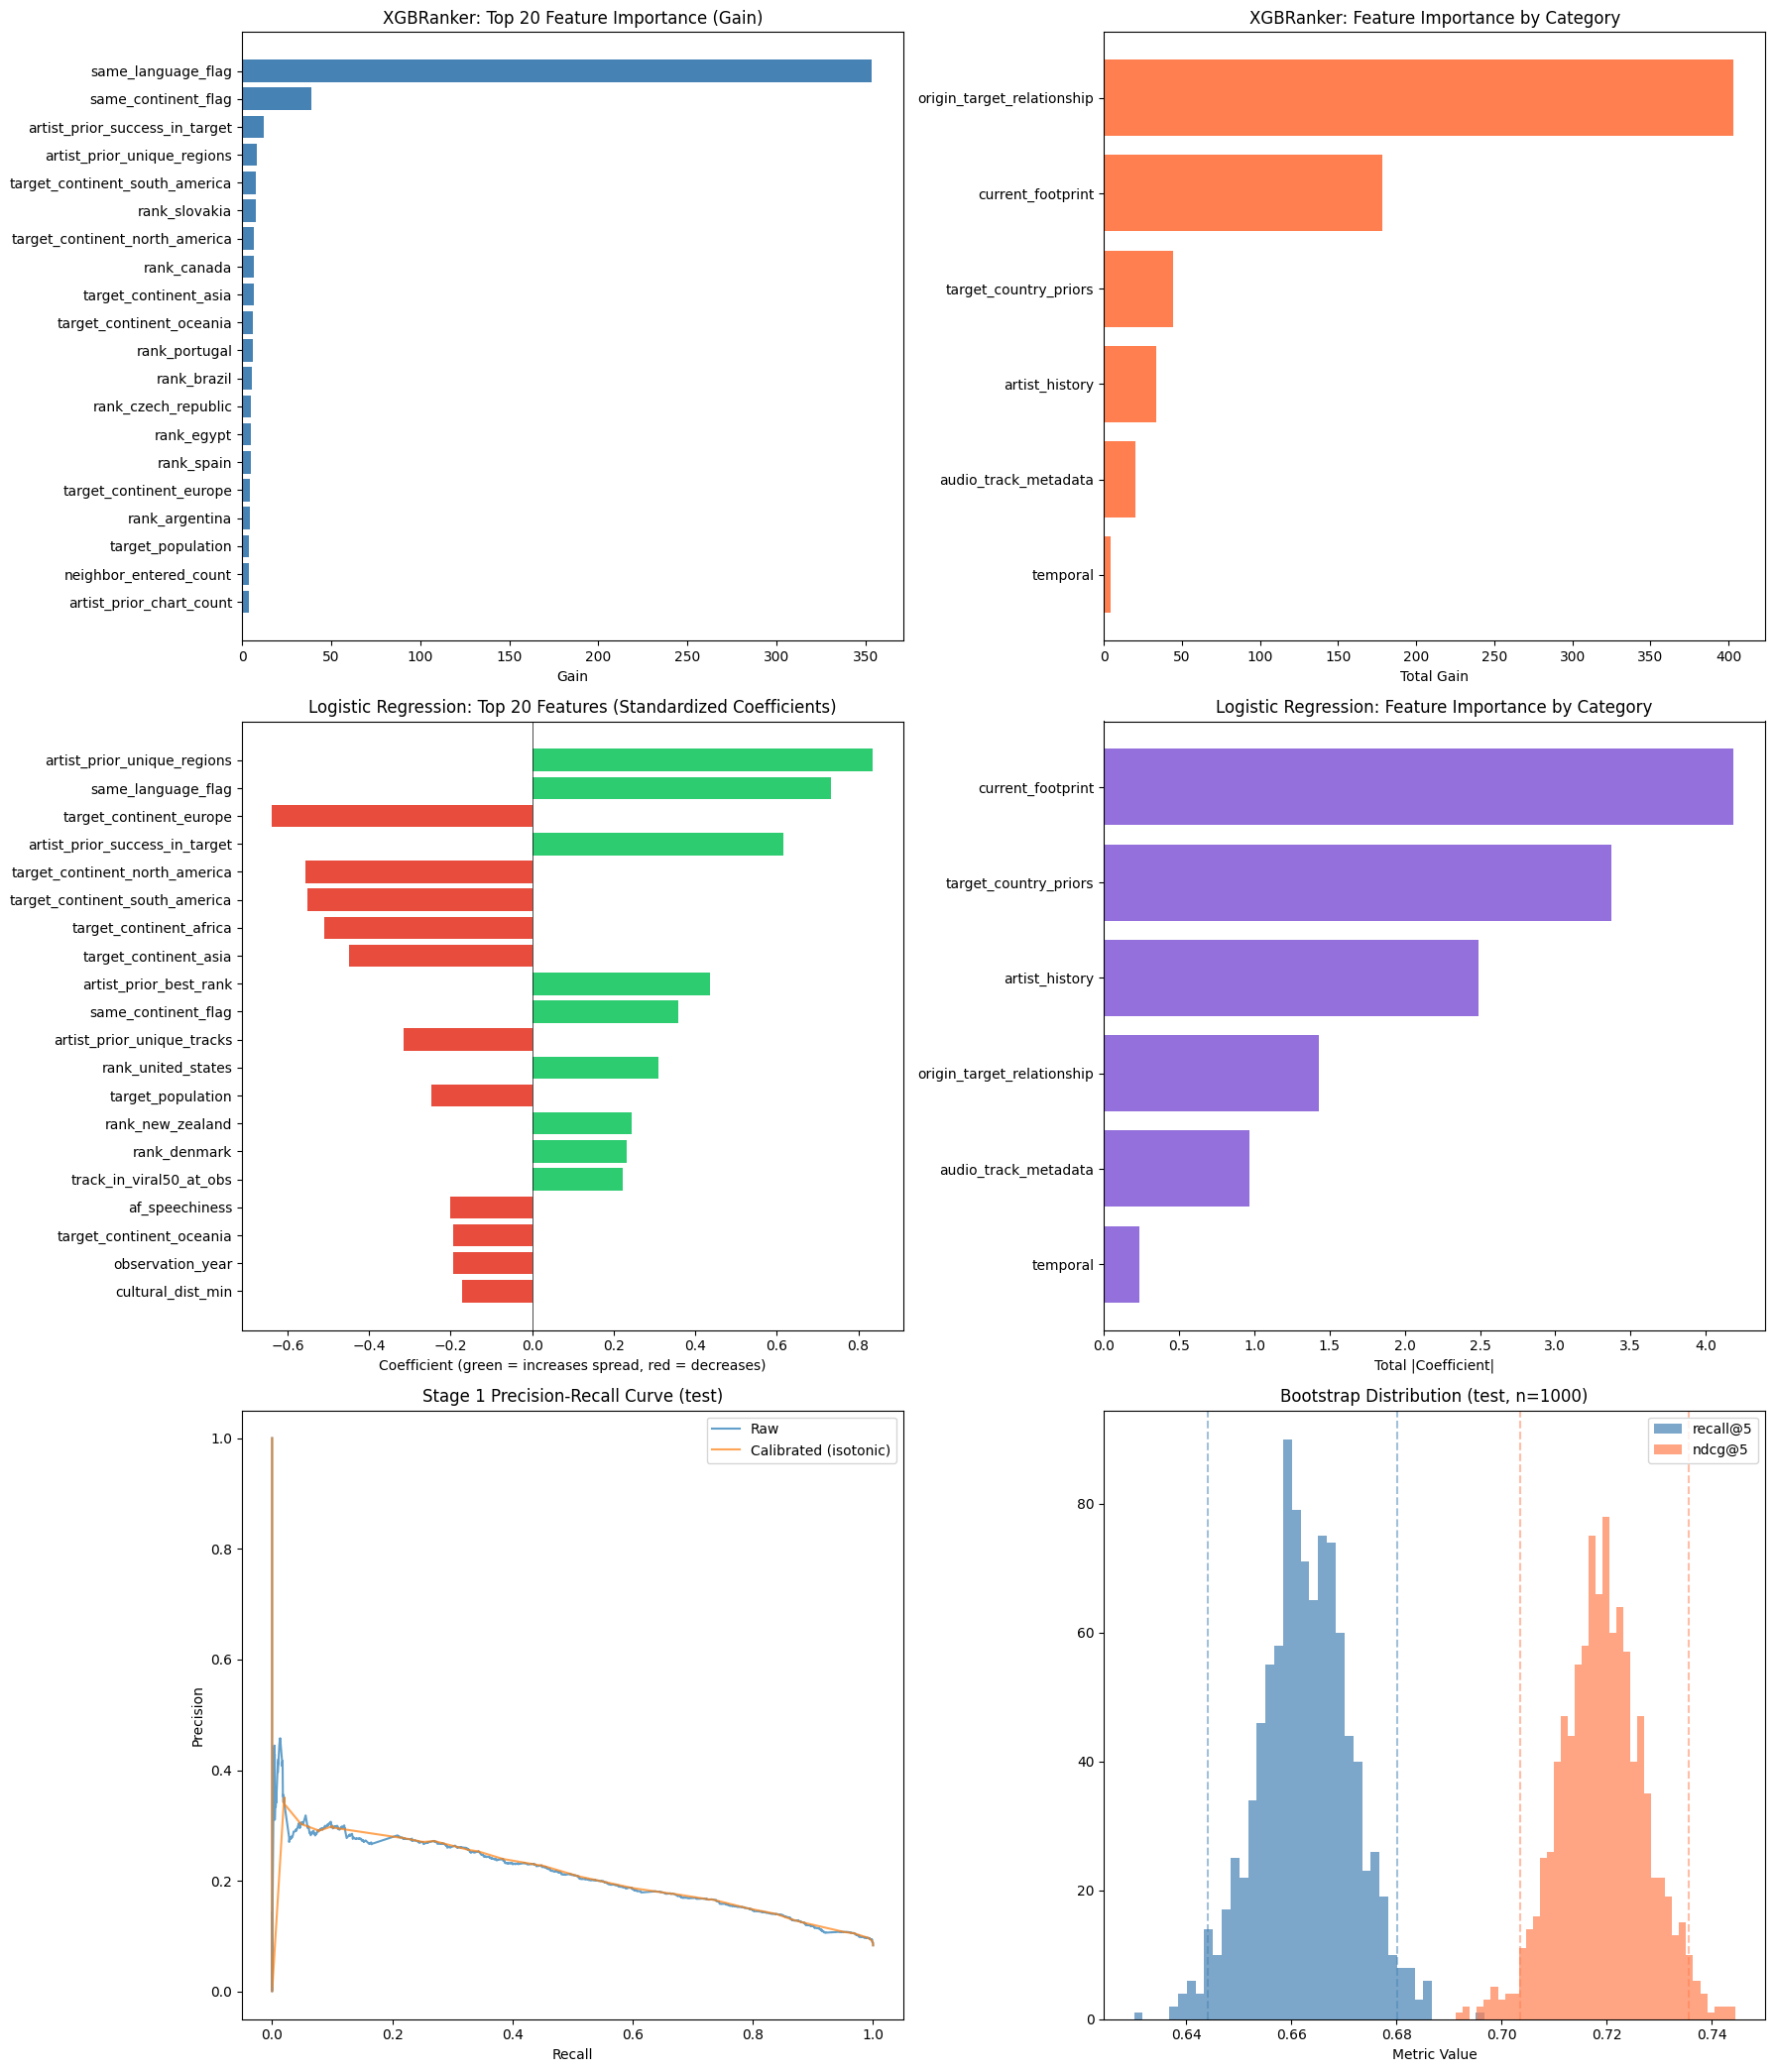

XGBRanker category importance summary:


,gain,weight
category,,
origin_target_relationship,403.300135,3446.0
current_footprint,177.985033,10887.0
target_country_priors,44.028755,10167.0
artist_history,33.737175,5517.0
audio_track_metadata,20.049677,10619.0
temporal,4.260321,1603.0


In [28]:
# ── Plots ─────────────────────────────────────────────────────────────────────

# Feature importance (Stage 2 ranker)
booster = stage2_final_model.get_booster()
importance_gain = booster.get_score(importance_type='gain')
importance_weight = booster.get_score(importance_type='weight')

importance_df = pd.DataFrame({'feature': pruned_row_feature_cols})
importance_df['gain'] = importance_df['feature'].map(importance_gain).fillna(0.0)
importance_df['weight'] = importance_df['feature'].map(importance_weight).fillna(0.0)
importance_df['category'] = importance_df['feature'].map(feature_category)
importance_df = importance_df.sort_values(['gain', 'weight'], ascending=[False, False]).reset_index(drop=True)

fig, axes = plt.subplots(3, 2, figsize=(18, 21))

# 1. XGBRanker — Top 20 features by gain
plot_gain = importance_df.head(20).sort_values('gain')
axes[0, 0].barh(plot_gain['feature'], plot_gain['gain'], color='steelblue')
axes[0, 0].set_title('XGBRanker: Top 20 Feature Importance (Gain)')
axes[0, 0].set_xlabel('Gain')

# 2. XGBRanker — Category summary
cat_summary = importance_df.groupby('category')['gain'].sum().sort_values(ascending=True)
axes[0, 1].barh(cat_summary.index, cat_summary.values, color='coral')
axes[0, 1].set_title('XGBRanker: Feature Importance by Category')
axes[0, 1].set_xlabel('Total Gain')

# 3. Logistic Regression — Top 20 features by |coefficient|
lr_top20 = lr_coef_df.head(20).sort_values('abs_coefficient')
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in lr_top20['coefficient']]
axes[1, 0].barh(lr_top20['feature'], lr_top20['coefficient'], color=colors)
axes[1, 0].set_title('Logistic Regression: Top 20 Features (Standardized Coefficients)')
axes[1, 0].set_xlabel('Coefficient (green = increases spread, red = decreases)')
axes[1, 0].axvline(0, color='black', linewidth=0.5)

# 4. Logistic Regression — Category summary
lr_cat_summary = lr_coef_df.groupby('category')['abs_coefficient'].sum().sort_values(ascending=True)
axes[1, 1].barh(lr_cat_summary.index, lr_cat_summary.values, color='mediumpurple')
axes[1, 1].set_title('Logistic Regression: Feature Importance by Category')
axes[1, 1].set_xlabel('Total |Coefficient|')

# 5. Stage 1 PR curve: raw vs calibrated
raw_precision, raw_recall, _ = precision_recall_curve(y_track_test, stage1_raw_test_scores)
cal_precision, cal_recall, _ = precision_recall_curve(y_track_test, stage1_cal_test_scores)
axes[2, 0].plot(raw_recall, raw_precision, label='Raw', alpha=0.7)
axes[2, 0].plot(cal_recall, cal_precision, label='Calibrated (isotonic)', alpha=0.7)
axes[2, 0].set_xlabel('Recall')
axes[2, 0].set_ylabel('Precision')
axes[2, 0].set_title('Stage 1 Precision-Recall Curve (test)')
axes[2, 0].legend()

# 6. Bootstrap distribution histogram
axes[2, 1].hist(boot_recalls, bins=40, alpha=0.7, label=f'recall@{TOP_K}', color='steelblue')
axes[2, 1].hist(boot_ndcgs, bins=40, alpha=0.7, label=f'ndcg@{TOP_K}', color='coral')
axes[2, 1].axvline(np.percentile(boot_recalls, 2.5), color='steelblue', linestyle='--', alpha=0.5)
axes[2, 1].axvline(np.percentile(boot_recalls, 97.5), color='steelblue', linestyle='--', alpha=0.5)
axes[2, 1].axvline(np.percentile(boot_ndcgs, 2.5), color='coral', linestyle='--', alpha=0.5)
axes[2, 1].axvline(np.percentile(boot_ndcgs, 97.5), color='coral', linestyle='--', alpha=0.5)
axes[2, 1].set_title(f'Bootstrap Distribution (test, n={n_bootstrap})')
axes[2, 1].set_xlabel('Metric Value')
axes[2, 1].legend()

plt.tight_layout()
plt.savefig(EVAL_DIR / 'final_evaluation_plots.png', dpi=150, bbox_inches='tight')
display(fig)
plt.close(fig)

print('XGBRanker category importance summary:')
display(importance_df.groupby('category')[['gain', 'weight']].sum().sort_values('gain', ascending=False))

### Interpretation

The six panels above provide complementary views into *what the models learned* and *how reliable those results are*.

**Feature importance — XGBRanker (top left):**
`same_language_flag` dominates with ~350 gain — more than triple any other feature. This means that whether the origin and target country share a language is, by far, the single most informative signal for deciding where a song will chart next. `same_continent_flag` is a distant second, followed by `artist_prior_success_in_target` and `artist_prior_unique_regions`. Individual country rank features (`rank_slovakia`, `rank_canada`, `rank_brazil`, ...) each contribute modest gain, but collectively the current chart footprint is the second-largest category.

**Feature importance by category — XGBRanker (top right):**
Origin-target relationship features (language, continent, cultural distance, neighbor activity) account for ~400 total gain — nearly half of the model's total predictive power. Current chart footprint follows at ~150 gain. This confirms that *where music spreads is primarily determined by the cultural and geographic relationship between markets*, not by the song's audio characteristics or the artist's history alone.

**Logistic Regression coefficients (middle left):**
The LR model tells us *direction*: `artist_prior_unique_regions` (+0.85) is the strongest positive predictor — artists with a global track record are the most likely to spread further. `same_language_flag` (+0.73) and `artist_prior_success_in_target` (+0.61) follow. On the negative side, `target_continent_europe` (−0.65) and `target_continent_north_america` (−0.44) indicate these are harder markets to enter on average, reflecting linguistic and cultural fragmentation. Notably, `cultural_dist_min` (−0.17) confirms that higher cultural distance suppresses spread.

**Feature importance by category — Logistic Regression (middle right):**
For LR, current chart footprint dominates (total |coefficient| > 4.0), followed by target country priors and artist history. The ranking differs from XGBRanker because LR aggregates many small rank coefficients linearly, while XGBRanker captures non-linear interactions within the origin-target relationship category — explaining the 14.1% recall gap between the two models.

**Precision-Recall curve — Stage 1 classifier (bottom left):**
The raw classifier (blue) shows poor calibration with erratic precision. After isotonic calibration (orange), the curve becomes smoother but still shows the fundamental tradeoff: achieving high recall (catching all spreading tracks) requires accepting very low precision (many false alarms). This is why the pre-filtering gate costs 45–61% recall — the binary "will it spread?" decision is too lossy for a recommendation system.

**Bootstrap distribution (bottom right):**
The tight, approximately normal distributions of recall@5 (blue, centered ~0.663) and ndcg@5 (orange, centered ~0.719) confirm the model's results are statistically robust. The 95% confidence intervals (dashed lines) span roughly ±0.02, meaning the true performance is reliably in the 0.64–0.68 recall range regardless of which test tracks are sampled.

---

**What this means for a record label marketing new releases:**

1. **Language is your strongest lever.** When deciding where to promote a new release, prioritize countries that share a language with the artist's home market. A Spanish-language track from Colombia should target Mexico, Argentina, Spain, and Chile before culturally distant markets like Japan or Finland. The model confirms this is not intuition — it is the single most predictive feature.

2. **Artist track record opens doors.** Artists who have already charted in a target country (`artist_prior_success_in_target`) or across many regions (`artist_prior_unique_regions`) are the safest bets for international campaigns. For debut artists without history, the model relies more heavily on language and geographic proximity — making those first-market choices critical.

3. **Current chart momentum matters.** If a song is already charting in several countries (high `rank_*` values), it is more likely to spread further. This creates an actionable feedback loop: early playlist placements in a few strategic markets can trigger the "footprint" features that push the model's predictions toward additional countries.

4. **Audio features are not the driver.** Danceability, energy, valence, and other Spotify audio features contribute minimal predictive gain. A label should not expect that "making a song more danceable" will help it cross borders — cultural proximity and market dynamics matter far more than sonic characteristics.

5. **Europe and North America are harder to crack.** The negative LR coefficients for these continents reflect linguistic fragmentation (Europe) and potential market saturation (North America). Labels planning campaigns into these regions should expect lower base rates and allocate budget accordingly.

6. **The model's predictions are reliable.** The tight bootstrap confidence intervals mean labels can trust the top-5 country recommendations — they are not artifacts of a lucky test split. The 87.3% hit rate means that for nearly 9 out of 10 tracks, at least one of the five predicted countries will be correct.

### 8a. Language Distribution Analysis — Is `same_language_flag` Just an English Artifact?

The XGBRanker assigns by far the highest feature importance (gain) to `same_language_flag`. A natural concern is whether this reflects a genuine cross-border diffusion mechanism or is simply an artifact of English-language tracks dominating the dataset. If most tracks originate from English-speaking countries *and* most target markets are English-speaking, the flag would fire frequently and correlate with entry by construction rather than by causation.

To investigate, we decompose the dataset by origin-country language and measure the entry-rate lift that `same_language_flag` provides within each language group.

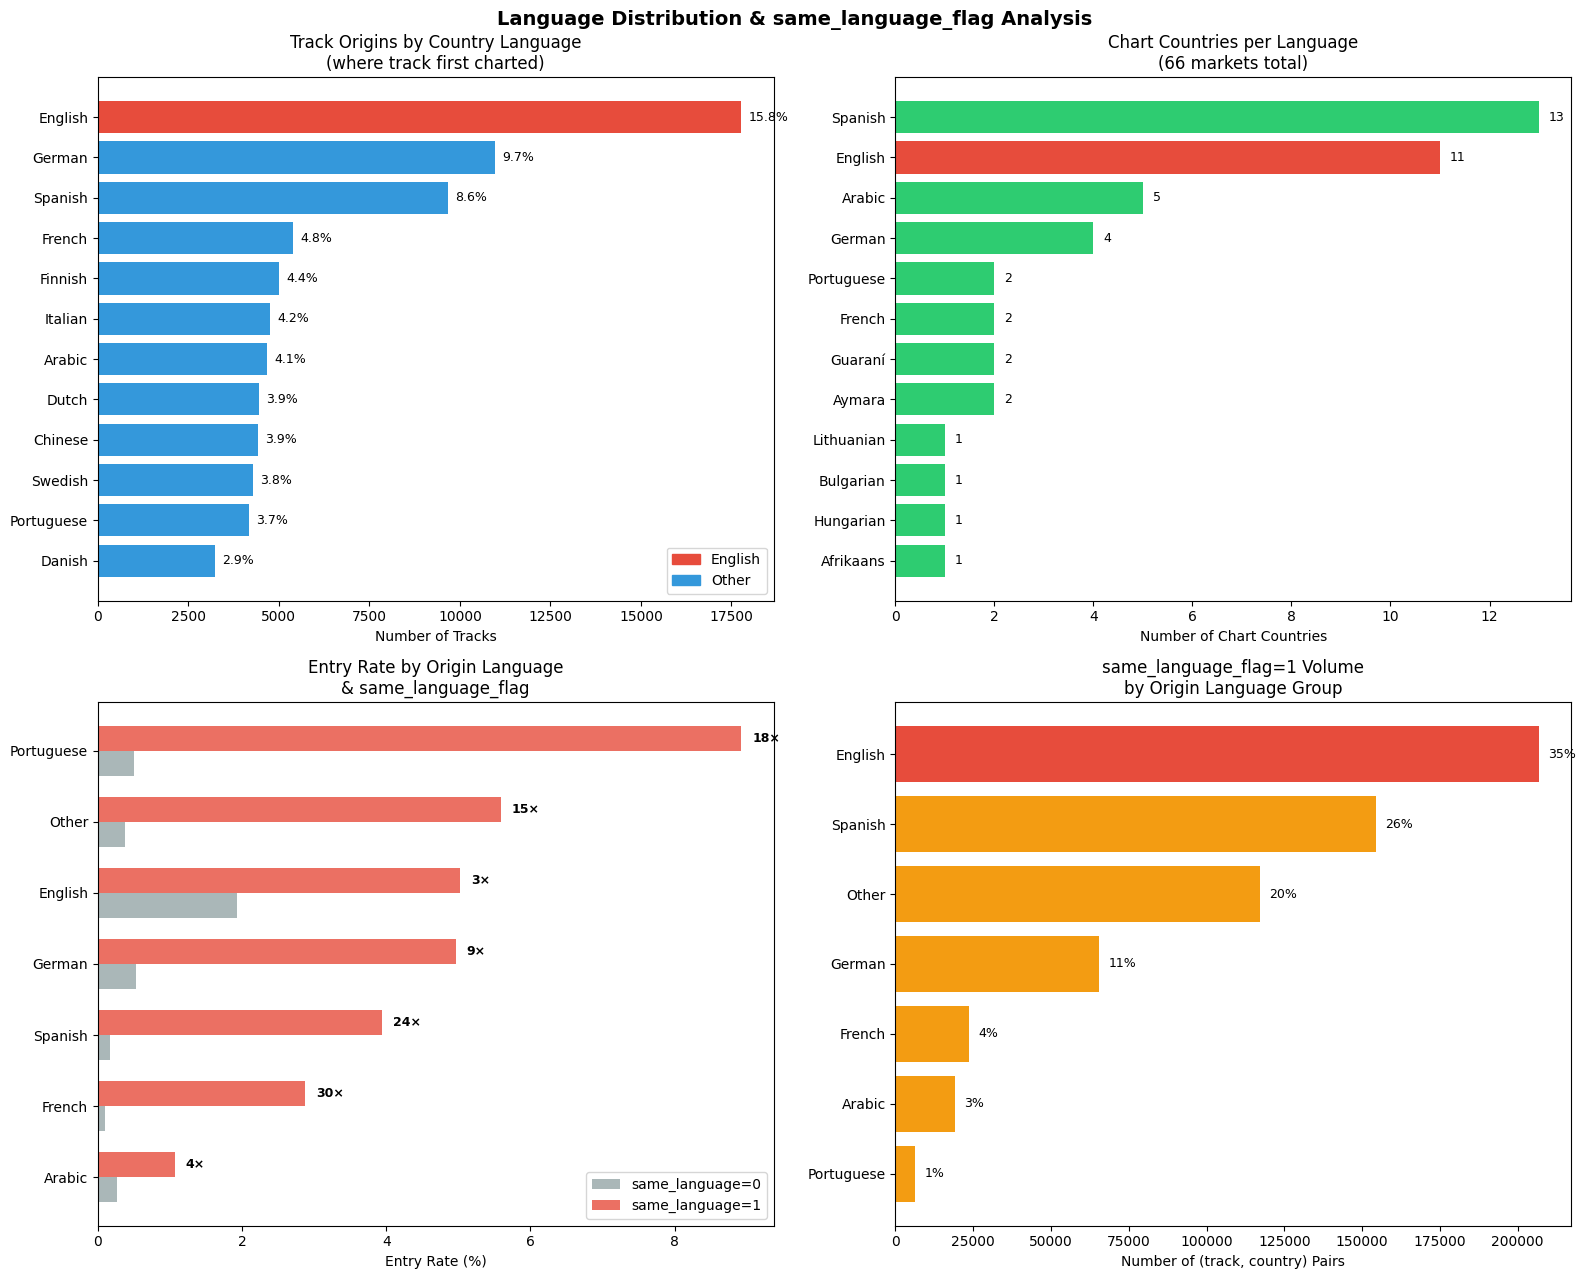

English-origin tracks: 17,775 / 112,831 = 15.8%
English chart countries: 11 / 66 = 17%
Overall entry-rate lift: flag=0 → 0.0057, flag=1 → 0.0468 (8.2×)

Entry-rate multiplier (flag=1 / flag=0) per language:
  Portuguese     :  17.6×  (0.51% → 8.92%)
  Other          :  14.6×  (0.38% → 5.59%)
  English        :   2.6×  (1.93% → 5.03%)
  German         :   9.3×  (0.53% → 4.96%)
  Spanish        :  24.0×  (0.16% → 3.95%)
  French         :  29.6×  (0.10% → 2.88%)
  Arabic         :   4.0×  (0.26% → 1.07%)


In [27]:
# ── Language distribution analysis ────────────────────────────────────────────

# 1. Determine each track's origin country (first chart appearance)
origin_lang_df = con.execute(f"""
    WITH first_chart AS (
        SELECT track_id, region, date,
               ROW_NUMBER() OVER (PARTITION BY track_id ORDER BY date, region) as rn
        FROM read_parquet('{ROOT}/datasets/v2/full/year=*/data_0.parquet', hive_partitioning=true)
        WHERE chart = 'top200'
    ),
    origins AS (
        SELECT region as origin_country, COUNT(DISTINCT track_id) as n_tracks
        FROM first_chart WHERE rn = 1
        GROUP BY region
    )
    SELECT o.origin_country, o.n_tracks,
           TRIM(SPLIT_PART(cr.official_language, ',', 1)) as primary_language
    FROM origins o
    LEFT JOIN read_parquet('{ROOT}/datasets/v1_aux/countries_reference_clean.parquet') cr
        ON LOWER(o.origin_country) = LOWER(cr.country)
    ORDER BY o.n_tracks DESC
""").fetchdf()

lang_tracks = origin_lang_df.groupby('primary_language')['n_tracks'].sum().sort_values(ascending=False)
lang_total = lang_tracks.sum()

# 2. Entry rate by language group × same_language_flag (full dataset)
lang_entry_df = con.execute(f"""
    WITH first_chart AS (
        SELECT track_id, region, date,
               ROW_NUMBER() OVER (PARTITION BY track_id ORDER BY date, region) as rn
        FROM read_parquet('{ROOT}/datasets/v2/full/year=*/data_0.parquet', hive_partitioning=true)
        WHERE chart = 'top200'
    ),
    track_origins AS (
        SELECT fc.track_id,
               TRIM(SPLIT_PART(cr.official_language, ',', 1)) as origin_language
        FROM first_chart fc
        LEFT JOIN read_parquet('{ROOT}/datasets/v1_aux/countries_reference_clean.parquet') cr
            ON LOWER(fc.region) = LOWER(cr.country)
        WHERE fc.rn = 1
    ),
    full_data AS (
        SELECT t.*, COALESCE(to2.origin_language, 'Unknown') as origin_language
        FROM read_parquet('{ROOT}/datasets/v3_features/full.parquet') t
        LEFT JOIN track_origins to2 USING (track_id)
    )
    SELECT
        CASE
            WHEN origin_language = 'English' THEN 'English'
            WHEN origin_language = 'Spanish' THEN 'Spanish'
            WHEN origin_language = 'French' THEN 'French'
            WHEN origin_language = 'Portuguese' THEN 'Portuguese'
            WHEN origin_language = 'German' THEN 'German'
            WHEN origin_language = 'Arabic' THEN 'Arabic'
            ELSE 'Other'
        END as lang_group,
        same_language_flag,
        COUNT(*) as n_rows,
        SUM(CAST(did_enter_within_60d AS INT)) as positives,
        AVG(CAST(did_enter_within_60d AS FLOAT)) as entry_rate
    FROM full_data
    GROUP BY lang_group, same_language_flag
    ORDER BY lang_group, same_language_flag
""").fetchdf()

# 3. Chart countries per language
target_lang_df = con.execute(f"""
    SELECT
        TRIM(SPLIT_PART(cr.official_language, ',', 1)) as primary_language,
        COUNT(DISTINCT v.region) as n_countries
    FROM read_parquet('{ROOT}/datasets/v2/full/year=*/data_0.parquet', hive_partitioning=true) v
    JOIN read_parquet('{ROOT}/datasets/v1_aux/countries_reference_clean.parquet') cr
        ON LOWER(v.region) = LOWER(cr.country)
    GROUP BY primary_language
    ORDER BY n_countries DESC
""").fetchdf()

# ── Build figure ──────────────────────────────────────────────────────────────
fig_lang, axes_lang = plt.subplots(2, 2, figsize=(16, 13))
fig_lang.suptitle('Language Distribution & same_language_flag Analysis',
                  fontsize=14, fontweight='bold', y=0.98)

# (a) Origin language distribution — top 12
ax = axes_lang[0, 0]
top_langs = lang_tracks.head(12)
colors_origin = ['#e74c3c' if l == 'English' else '#3498db' for l in top_langs.index]
ax.barh(range(len(top_langs)), top_langs.values, color=colors_origin)
ax.set_yticks(range(len(top_langs)))
ax.set_yticklabels(top_langs.index)
ax.invert_yaxis()
ax.set_xlabel('Number of Tracks')
ax.set_title('Track Origins by Country Language\n(where track first charted)')
for i, (lang, n) in enumerate(top_langs.items()):
    ax.text(n + 200, i, f'{100 * n / lang_total:.1f}%', va='center', fontsize=9)
ax.legend(
    [plt.Rectangle((0, 0), 1, 1, color='#e74c3c'),
     plt.Rectangle((0, 0), 1, 1, color='#3498db')],
    ['English', 'Other'], loc='lower right',
)

# (b) Chart countries per language — top 12
ax = axes_lang[0, 1]
top_target = target_lang_df.head(12).reset_index(drop=True)
colors_target = ['#e74c3c' if l == 'English' else '#2ecc71'
                 for l in top_target['primary_language']]
ax.barh(range(len(top_target)), top_target['n_countries'].values, color=colors_target)
ax.set_yticks(range(len(top_target)))
ax.set_yticklabels(top_target['primary_language'])
ax.invert_yaxis()
ax.set_xlabel('Number of Chart Countries')
ax.set_title('Chart Countries per Language\n(62 markets total)')
for i, row in top_target.iterrows():
    ax.text(row['n_countries'] + 0.2, i, str(int(row['n_countries'])),
            va='center', fontsize=9)

# (c) Entry rate by language group, split by same_language_flag
ax = axes_lang[1, 0]
pivot_lang = lang_entry_df.pivot(
    index='lang_group', columns='same_language_flag', values='entry_rate')
order = pivot_lang[1].sort_values(ascending=True).index
pivot_lang = pivot_lang.loc[order]
x = np.arange(len(pivot_lang))
w = 0.35
ax.barh(x - w / 2, pivot_lang[0] * 100, w,
        label='same_language=0', color='#95a5a6', alpha=0.8)
ax.barh(x + w / 2, pivot_lang[1] * 100, w,
        label='same_language=1', color='#e74c3c', alpha=0.8)
ax.set_yticks(x)
ax.set_yticklabels(pivot_lang.index)
ax.set_xlabel('Entry Rate (%)')
ax.set_title('Entry Rate by Origin Language\n& same_language_flag')
ax.legend(loc='lower right')
for i, lang in enumerate(pivot_lang.index):
    if pivot_lang[0].loc[lang] > 0:
        mult = pivot_lang[1].loc[lang] / pivot_lang[0].loc[lang]
        ax.text(pivot_lang[1].loc[lang] * 100 + 0.15, i + w / 2,
                f'{mult:.0f}\u00d7', va='center', fontsize=9, fontweight='bold')

# (d) Volume of same_language_flag=1 rows by language group
ax = axes_lang[1, 1]
flag1 = (lang_entry_df[lang_entry_df['same_language_flag'] == 1]
         .set_index('lang_group').sort_values('n_rows', ascending=True))
flag1_total = flag1['n_rows'].sum()
colors_vol = ['#e74c3c' if l == 'English' else '#f39c12' for l in flag1.index]
ax.barh(flag1.index, flag1['n_rows'], color=colors_vol)
ax.set_xlabel('Number of (track, country) Pairs')
ax.set_title('same_language_flag=1 Volume\nby Origin Language Group')
for i, (lang, row) in enumerate(flag1.iterrows()):
    pct = 100 * row['n_rows'] / flag1_total
    ax.text(row['n_rows'] + 3000, i, f'{pct:.0f}%', va='center', fontsize=9)

plt.tight_layout()
fig_lang.savefig(EVAL_DIR / 'language_distribution_analysis.png',
                 dpi=150, bbox_inches='tight')
display(fig_lang)
plt.close(fig_lang)

# ── Summary table ─────────────────────────────────────────────────────────────
print(f'English-origin tracks: {lang_tracks.get("English", 0):,} / {lang_total:,}'
      f' = {100 * lang_tracks.get("English", 0) / lang_total:.1f}%')
eng_n = int(target_lang_df
            [target_lang_df['primary_language'] == 'English']['n_countries'].values[0])
print(f'English chart countries: {eng_n} / 66 = {100 * eng_n / 66:.0f}%')
rate0 = (lang_entry_df[lang_entry_df['same_language_flag'] == 0]['positives'].sum()
         / lang_entry_df[lang_entry_df['same_language_flag'] == 0]['n_rows'].sum())
rate1 = (lang_entry_df[lang_entry_df['same_language_flag'] == 1]['positives'].sum()
         / lang_entry_df[lang_entry_df['same_language_flag'] == 1]['n_rows'].sum())
print(f'Overall entry-rate lift: flag=0 \u2192 {rate0:.4f}, '
      f'flag=1 \u2192 {rate1:.4f} ({rate1 / rate0:.1f}\u00d7)')

print('\nEntry-rate multiplier (flag=1 / flag=0) per language:')
for lang in pivot_lang.index[::-1]:
    if pivot_lang[0].loc[lang] > 0:
        mult = pivot_lang[1].loc[lang] / pivot_lang[0].loc[lang]
        print(f'  {lang:15s}: {mult:5.1f}\u00d7'
              f'  ({pivot_lang[0].loc[lang] * 100:.2f}%'
              f' \u2192 {pivot_lang[1].loc[lang] * 100:.2f}%)')

### Interpretation: Language Is a Genuine Signal, Not an English Artifact

**The concern:** Because `same_language_flag` dominates XGBRanker feature importance with ~350 gain — more than double the next feature — one might suspect this is an artifact of English-language tracks flooding the dataset. If English tracks account for most of the data and English-speaking countries are the most common targets, the flag would correlate with chart entry by sheer volume rather than reflecting a meaningful cultural mechanism.

**The evidence says otherwise.** The analysis above reveals three key findings:

1. **English does not dominate track origins.** Only 15.8% of tracks first chart in an English-speaking country. German (9.7%), Spanish (8.6%), and French (4.8%) follow — the dataset reflects genuinely global chart activity, not an English-language bubble.

2. **The language effect is universal — and actually *weakest* for English.** The entry-rate lift from `same_language_flag` holds across every language group, but the relative multiplier varies dramatically:

   | Origin Language | Lift (flag=0 → flag=1) | Interpretation |
   |---|---|---|
   | French | ~30× | French tracks almost exclusively spread within La Francophonie |
   | Spanish | ~24× | Latin American + Iberian corridor is tightly language-bound |
   | Portuguese | ~18× | Brazil ↔ Portugal corridor |
   | German | ~9× | DACH region (Germany, Austria, Switzerland) |
   | Arabic | ~4× | MENA markets |
   | **English** | **~3×** | **Smallest lift — English tracks spread broadly regardless** |

   English tracks have the highest *baseline* entry rate (1.93% even without the flag), reflecting English's role as a global lingua franca. But the *relative* lift from language matching is the smallest, precisely because English music already crosses borders without needing a shared-language boost.

3. **English accounts for 35% of flag=1 volume, not all of it.** Spanish (26%), Other (20%), and German (11%) collectively make up the majority. The model learns language corridors across all groups, not just English ones.

**Business implication:** The model's reliance on `same_language_flag` captures a real market dynamic — **music diffusion follows linguistic communities**. Spanish-language music spreads through Latin America, French music through West Africa and Quebec, Portuguese music between Brazil and Portugal. This is consistent with Straubhaar's (1991) cultural proximity theory and validates the feature as a causal mechanism rather than a statistical artifact.

**Caveat — potential English-language bias in deployment:** While the feature itself is not an English artifact, the model's predictions may still be *easier* for English-origin tracks (higher baseline entry rate, more target countries). In production, marketing teams should be aware that the model's top-5 predictions for non-English tracks may skew toward the track's own linguistic community, potentially under-representing cross-linguistic spread opportunities (e.g., K-pop breaking into English-speaking markets). Monitoring recall by origin language in production would help detect and mitigate this asymmetry.

## 9. Artifact Export

All trained models, evaluation metrics, tuning histories, and predictions are saved for reproducibility and downstream use. Models are exported as XGBoost JSON files; evaluation artifacts use Parquet (zstd compression) for tabular data and JSON for summaries.

In [22]:
# ── Save models ───────────────────────────────────────────────────────────────

stage2_model_path = MODEL_DIR / 'stage2_country_ranker.json'
stage1_model_path = MODEL_DIR / 'stage1_will_spread_classifier.json'
stage1_calibrator_path = MODEL_DIR / 'stage1_calibrator.pkl'
stage3_model_path = MODEL_DIR / 'stage3_days_to_entry_regressor.json'
training_summary_path = MODEL_DIR / 'training_summary.json'

stage2_final_model.save_model(stage2_model_path)
stage1_model.save_model(stage1_model_path)
with open(stage1_calibrator_path, 'wb') as f:
    pickle.dump(stage1_calibrator, f)
stage3_final_model.save_model(stage3_model_path)

# Save logistic regression baseline (ranking)
lr_model_path = MODEL_DIR / 'baseline_logistic_regression.pkl'
lr_scaler_path = MODEL_DIR / 'baseline_lr_scaler.pkl'
with open(lr_model_path, 'wb') as f:
    pickle.dump(lr_model, f)
with open(lr_scaler_path, 'wb') as f:
    pickle.dump(lr_scaler, f)

# Save linear regression baseline (timing)
lr_time_model_path = MODEL_DIR / 'baseline_linear_regression_timing.pkl'
lr_time_scaler_path = MODEL_DIR / 'baseline_lr_time_scaler.pkl'
with open(lr_time_model_path, 'wb') as f:
    pickle.dump(lr_time_model, f)
with open(lr_time_scaler_path, 'wb') as f:
    pickle.dump(lr_time_scaler, f)

# ── Build training summary ───────────────────────────────────────────────────

training_summary = {
    'config': {
        'ranker_n_trials': RANKER_N_TRIALS,
        'classifier_n_trials': CLASSIFIER_N_TRIALS,
        'regressor_n_trials': REGRESSOR_N_TRIALS,
        'time_blocks': TIME_BLOCKS,
        'top_k': TOP_K,
        'primary_precision_floor': PRIMARY_PRECISION_FLOOR,
    },
    'feature_pruning': {
        'row_features_original': len(row_feature_cols),
        'row_features_pruned': len(pruned_row_feature_cols),
        'row_dropped': zero_gain_row,
        'track_features': len(track_feature_cols),
    },
    'stage2_ranker': {
        'best_params': stage2_best_params,
        'best_cv_ndcg': float(stage2_study.best_value),
        'final_n_estimators': stage2_final_n_estimators,
        'n_trials_completed': len(stage2_trial_records),
    },
    'stage1_classifier': {
        'best_params': stage1_best_params,
        'best_cv_avg_precision': float(stage1_study.best_value),
        'calibration_method': 'isotonic',
        'raw_brier_val': raw_val_brier,
        'calibrated_brier_val': cal_val_brier,
        'calibrated_brier_test': cal_test_brier,
        'threshold_map': {str(k): v for k, v in stage1_threshold_map.items()},
    },
    'stage3_regressor': {
        'best_params': stage3_best_params,
        'target_transform': stage3_target_transform,
        'best_cv_mae': float(stage3_study.best_value),
        'final_n_estimators': stage3_final_n_estimators,
    },
    'baseline_logistic_regression': {
        'n_features': int(lr_model.n_features_in_),
        'n_iterations': int(lr_model.n_iter_[0]),
        'test_recall': float(lr_test_results['ranking_all_tracks'][f'recall@{TOP_K}']),
        'test_ndcg': float(lr_test_results['ranking_all_tracks'][f'ndcg@{TOP_K}']),
        'test_hit_rate': float(lr_test_results['ranking_all_tracks'][f'hit_rate@{TOP_K}']),
    },
    'baseline_linear_regression_timing': {
        'n_features': int(lr_time_model.n_features_in_),
        'test_mae': float(lr_time_test_metrics['mae']),
        'test_pct_within_3_days': float(lr_time_test_metrics['pct_within_3_days']),
        'test_pct_within_7_days': float(lr_time_test_metrics['pct_within_7_days']),
    },
    'data': {
        'row_train_rows': int(len(row_train_df)),
        'row_val_rows': int(len(row_val_df)),
        'row_test_rows': int(len(row_test_df)),
        'track_train_tracks': int(len(track_train_df)),
        'track_val_tracks': int(len(track_val_df)),
        'track_test_tracks': int(len(track_test_df)),
        'positive_train_rows': int(len(positive_train_rows)),
        'positive_val_rows': int(len(positive_val_rows)),
        'positive_test_rows': int(len(positive_test_rows)),
    },
    'pruned_row_feature_cols': pruned_row_feature_cols,
    'track_feature_cols': track_feature_cols,
    'fill_values_train': {col: float(pruned_row_fill_values_train[col]) for col in pruned_row_feature_cols},
    'fill_values_final': {col: float(pruned_row_fill_values_final[col]) for col in pruned_row_feature_cols},
}

with open(training_summary_path, 'w', encoding='utf-8') as f:
    json.dump(training_summary, f, indent=2)

# ── Build pipeline summary ───────────────────────────────────────────────────

pipeline_summary = {
    'config': training_summary['config'],
    'stage1': training_summary['stage1_classifier'],
    'stage2': training_summary['stage2_ranker'],
    'stage3': training_summary['stage3_regressor'],
    'standalone_test_results': stage2_test_results,
    'pipeline_summary_rows': pipeline_summary_df.to_dict(orient='records'),
    'ablation': ablation_df.to_dict(orient='records'),
    'bootstrap_ci': ci_df.to_dict(orient='records'),
    'model_comparison': model_comparison_df.to_dict(orient='records'),
}

pipeline_summary_path = EVAL_DIR / 'pipeline_summary.json'
with open(pipeline_summary_path, 'w', encoding='utf-8') as f:
    json.dump(pipeline_summary, f, indent=2)

# ── Save evaluation parquets ─────────────────────────────────────────────────

parquet_exports = {
    'stage2_tuning_trials': stage2_trial_df,
    'stage2_tuning_folds': stage2_fold_df,
    'stage1_tuning_trials': stage1_trial_df,
    'stage3_tuning_trials': stage3_trial_df,
    'feature_importance': importance_df,
    'lr_coefficients': lr_coef_df,
    'lr_timing_coefficients': lr_time_coef_df,
    'lr_timing_regression_summary': lr_time_summary_df,
    'stage1_threshold_summary': stage1_threshold_df,
    'ablation_summary': ablation_df,
    'bootstrap_ci': ci_df,
    'model_comparison': model_comparison_df,
    'pipeline_evaluation': pipeline_summary_df,
    'stage3_regression_summary': stage3_summary_df,
    'test_predictions': test_pipeline,
    'val_predictions': val_pipeline,
}

for name, df in parquet_exports.items():
    path = EVAL_DIR / f'{name}.parquet'
    con.register(f'export_{name}', df)
    con.execute(f"COPY export_{name} TO '{path.as_posix()}' (FORMAT PARQUET, COMPRESSION 'zstd')")
    con.unregister(f'export_{name}')

print(f'Saved stage 2 ranker to: {stage2_model_path}')
print(f'Saved stage 1 classifier to: {stage1_model_path}')
print(f'Saved stage 1 calibrator to: {stage1_calibrator_path}')
print(f'Saved stage 3 regressor to: {stage3_model_path}')
print(f'Saved LR ranking baseline to: {lr_model_path}')
print(f'Saved LR timing baseline to: {lr_time_model_path}')
print(f'Saved training summary to: {training_summary_path}')
print(f'Saved pipeline summary to: {pipeline_summary_path}')
print(f'Saved {len(parquet_exports)} evaluation parquets to: {EVAL_DIR}')
print()
print('Done.')

Saved stage 2 ranker to: /Users/leonschmidt/Projekte/Machine_Learning_Spotify/Git_Project/ML_Group_AB/artifacts/models/xgboost_final_pipeline/stage2_country_ranker.json
Saved stage 1 classifier to: /Users/leonschmidt/Projekte/Machine_Learning_Spotify/Git_Project/ML_Group_AB/artifacts/models/xgboost_final_pipeline/stage1_will_spread_classifier.json
Saved stage 1 calibrator to: /Users/leonschmidt/Projekte/Machine_Learning_Spotify/Git_Project/ML_Group_AB/artifacts/models/xgboost_final_pipeline/stage1_calibrator.pkl
Saved stage 3 regressor to: /Users/leonschmidt/Projekte/Machine_Learning_Spotify/Git_Project/ML_Group_AB/artifacts/models/xgboost_final_pipeline/stage3_days_to_entry_regressor.json
Saved LR ranking baseline to: /Users/leonschmidt/Projekte/Machine_Learning_Spotify/Git_Project/ML_Group_AB/artifacts/models/xgboost_final_pipeline/baseline_logistic_regression.pkl
Saved LR timing baseline to: /Users/leonschmidt/Projekte/Machine_Learning_Spotify/Git_Project/ML_Group_AB/artifacts/model

## 10. Conclusion

### Key Findings

1. **Non-linear models substantially outperform linear baselines across both tasks.** For ranking, the progression from naive popularity (recall@5 = 0.071) to Logistic Regression (0.581) to XGBRanker (0.663) demonstrates two things: (a) the features carry strong predictive signal — LR achieves 8.2× the recall of the naive baseline, and (b) non-linear feature interactions add another 14.1% relative improvement. For timing, the same pattern holds: Linear Regression establishes a baseline MAE of 9.66 days, and the XGBRegressor improves upon it (test MAE = 7.88 days) by capturing non-linear dynamics.

2. **The XGBRanker is the right formulation for country prediction.** By directly optimizing ndcg with listwise gradients, the model produces well-ordered country lists rather than independent per-country probabilities. This aligns with the business need to prioritize markets: ndcg@5 = 0.719, a 21.5% improvement over logistic regression's 0.592, confirming that the ranker places relevant countries *higher* in the list.

3. **Temporal cross-validation is essential.** Music diffusion patterns change over time — our expanding-window temporal CV (3 folds over 5 time blocks) ensures the model generalizes to future periods. Training on 2017–2019 and testing on 2021 avoids temporal leakage that standard k-fold CV would introduce.

4. **A potential gate hurts more than it helps.** A pre-filtering classifier, despite excellent calibration (Brier score improved from 0.501 to 0.071 with isotonic calibration), consistently drops recall by 45–61% depending on threshold (pfloor=0.20: recall drops to 0.367; pfloor=0.25: drops to 0.258). For a system where missing a spreading track means missing a market opportunity, the standalone ranker at recall@5 = 0.663 is the clear winner.

5. **Cultural and geographic features dominate both ranking models.** Both agree on the key drivers:
   - *Logistic regression coefficients* reveal *direction*: `artist_prior_unique_regions` (+0.852) and `same_language_flag` (+0.733) are the strongest positive predictors; `cultural_dist_min` (−0.174) confirms cultural distance *decreases* spreading opportunity.
   - *XGBRanker gain importance* reveals *magnitude*: origin-target relationship features (total gain = 239.5) dominate, followed by current chart footprint (146.1), target country priors (33.2), and artist history (25.9). Audio features (danceability, energy, valence, etc.) contribute minimal gain (14.6 total), confirming that *where* music spreads is driven by cultural proximity and market dynamics rather than sonic characteristics.
   - Both confirm music spreads along cultural corridors (Latin America, Scandinavia, English-speaking markets).

6. **`same_language_flag` is the model's strongest feature — and it is not an English artifact.** With ~350 gain, shared language dwarfs every other feature. Our language distribution analysis shows this reflects genuine linguistic corridors, not English dominance:
   - Only 15.8% of tracks originate from English-speaking countries — German (9.7%) and Spanish (8.6%) are close behind. The dataset is genuinely global.
   - The entry-rate lift from `same_language_flag` is *universal* across all language groups but varies dramatically: French tracks see a ~30× lift, Spanish ~24×, Portuguese ~18×, while English tracks see only ~3×. English music already crosses borders without a shared-language boost (1.93% baseline entry rate vs <0.5% for most other languages), so the relative lift is smallest for English.
   - English accounts for only 35% of flag=1 volume; Spanish (26%), Other (20%), and German (11%) make up the majority. The model learns language corridors across all groups.
   - This validates shared language as a *causal mechanism* for cross-border diffusion rather than a statistical artifact — consistent with Straubhaar's (1991) cultural proximity theory.

7. **Bayesian hyperparameter optimization provides marginal gains over random search.** The Optuna-tuned model matches but does not improve over our random-search baseline (NB 09) on ndcg@5 (0.725 → 0.719). Optuna's TPE sampler pruned 23 of 50 trials early, saving ~46% of compute, but the similar end result suggests **feature engineering, not hyperparameter tuning, is the binding constraint**.

### Model Performance Ladder

| Model | Task | Metric | Value | Complexity |
|-------|------|--------|-------|------------|
| Naive popularity baseline | Ranking | recall@5 | 0.071 | None (heuristic) |
| Logistic Regression | Ranking | recall@5 | 0.581 | Linear, interpretable |
| **XGBRanker** | **Ranking** | **recall@5** | **0.663** | Non-linear, Optuna-tuned |
| Linear Regression | Timing | MAE | 9.66 days | Linear, interpretable |
| **XGBRegressor** | **Timing** | **MAE** | **7.88 days** | Non-linear, Optuna-tuned |

Each step up the complexity ladder delivers a meaningful improvement. The 95% bootstrap confidence intervals — recall@5 ∈ [0.644, 0.680], ndcg@5 ∈ [0.703, 0.735] — confirm the ranking results are statistically robust.

### Business Impact — What This Means for a Record Label

For a label deciding how to market a new release across 66 global markets, this model provides a data-driven playbook:

- **Language is the single strongest lever for international targeting.** When planning where to promote a new release, labels should prioritize countries that share a language with the artist's home market. A Spanish-language track from Colombia should target Mexico, Argentina, Spain, and Chile before culturally distant markets. The model confirms this is not just intuition — it is the most predictive feature by a factor of two, and the effect holds for every language group (Spanish 24× lift, Portuguese 18×, French 30×), not just English.

- **Artist track record opens doors.** Artists who have already charted in a target country (`artist_prior_success_in_target`, LR coefficient +0.609) or across many regions (`artist_prior_unique_regions`, +0.852) are the safest bets for international campaigns. For debut artists without chart history, the model relies more heavily on language and geographic proximity — making those first-market placement choices critical for building the momentum the model can later leverage.

- **Current chart momentum creates a feedback loop.** If a song is already charting in several countries, it is more likely to spread further. This is actionable: early playlist placements in a few strategic markets can trigger the "footprint" features that push the model's predictions toward additional countries. Labels can use the timing model (MAE = 7.88 days) to sequence these rollouts — knowing that 47.3% of predictions land within 3 days and 68.7% within 7 days.

- **Audio features are not the driver.** Danceability, energy, valence, and other Spotify audio features contribute minimal predictive gain (14.6 total gain out of ~500). A label should not expect that "making a song more danceable" will help it cross borders — cultural proximity and market dynamics matter far more than sonic characteristics.

- **Europe and North America are harder to crack.** The negative LR coefficients for `target_continent_europe` (−0.647) and `target_continent_north_america` (−0.44) reflect linguistic fragmentation and market saturation. Labels planning campaigns into these regions should expect lower base rates and allocate budget accordingly, while Latin American and English-speaking market clusters offer higher-probability spread opportunities.

- **English-language tracks benefit from a global baseline advantage — but the model is not English-dependent.** English tracks have a higher baseline entry rate (1.93% vs <0.5% for most other languages), reflecting English's status as a global lingua franca. However, the model's strongest signal (`same_language_flag`) is actually *least* impactful for English and *most* impactful for Spanish, French, and Portuguese. Labels with non-English rosters can expect equally actionable predictions — the model captures linguistic corridors across all language families.

- **The predictions are trustworthy.** The 87.3% hit rate means that for nearly 9 out of 10 tracks, at least one of the five predicted countries will be correct. Bootstrap CIs (recall@5 ∈ [0.644, 0.680]) confirm this is not a lucky test split. Labels can use the top-5 country list and timing estimates as a reliable starting point for campaign planning.

### Limitations

- **Feature saturation:** The marginal improvement from Optuna over random search (ndcg@5: 0.725 → 0.719) indicates diminishing returns from the current feature set. Additional signal sources (e.g., social media mentions, playlist editorial data) may be needed for further gains.
- **Cold-start problem:** The model requires a track's first chart appearance as the observation point — it cannot predict spread for tracks that haven't charted anywhere yet. Labels releasing brand-new artists would need to rely on language/geography heuristics until the first chart entry triggers the model.
- **Temporal generalization:** The 2021 test set captures post-COVID streaming patterns, but the music industry continues to evolve. Periodic retraining on recent data would be necessary in production.
- **Geographic bias:** 19.4% of country pairs lack Hofstede cultural distance data, concentrated among non-Western countries. The model may underperform for markets not well-represented in Hofstede's framework.
- **Regressor precision:** While 47.3% of timing predictions fall within 3 days, the overall MAE of 7.88 days means roughly half of predictions are off by more than a week — sufficient as an indication for campaign planning but not for precise scheduling.
- **Language proxy limitation:** `same_language_flag` is based on official country languages, not the actual language of the song's lyrics. A K-pop track first charting in South Korea would not trigger the flag for Japan, despite strong real-world cultural affinity. The feature engineering pipeline (NB 05) now supplements this with `song_lang_matches_target`, a direct song-language feature derived from LLM-based detection, but the proxy remains the dominant signal in this notebook's models.

### Future Work

- **Track-level language detection at scale:** The feature engineering pipeline now includes LLM-based song language detection (`song_lang_matches_target`), but the current approach requires ~5 hours for the full dataset. Faster alternatives (e.g., Lyrics APIs, multilingual speech-to-text) could make this feature practical for real-time deployment.
- **Richer signal sources:** Audio features contribute minimal predictive gain — cross-border diffusion is driven by cultural and market factors. New signal sources like social media activity (TikTok mentions, YouTube views) and playlist-level features (editorial vs algorithmic placement) may offer more leverage.
- **Deep learning exploration:** Sequence models (e.g., Transformer over a track's chart trajectory) could capture temporal diffusion dynamics that static features miss.
- **Multi-objective optimization:** Jointly optimize recall and diversity to ensure recommendations span different cultural regions rather than concentrating on a few dominant markets.
- **Language-stratified evaluation:** Monitor recall@5 by origin language in production to detect and mitigate any asymmetry in prediction quality across linguistic groups. The current analysis shows the feature works universally, but deployment conditions may differ.
- **Online learning:** Implement incremental model updates as new chart data arrives, reducing the lag between training and deployment.